#Proyecto: Análisis de cancelaciones en pedidos de delivery


## 1. Objetivo del proyecto

Disminución y prevención de cancelaciones en pedidos de delivery mediante el análisis de factores comerciales, operativos, climáticos y de comportamiento del cliente.

1.  Analizar el comportamiento de compra de los clientes
2.  Evaluar el desempeño operativo de las entregas
3.  Identificar factores asociados a una mayor probabilidad de cancelación
4.  Analizar el impacto de descuentos y promociones
5.  Evaluar la relación entre la ciudad, los tiempos de entrega y el nivel del cliente con la tasa de cancelación de pedidos
6.  Desarrollar estrategias de optimización del servicio de delivery, orientadas a reducir cancelaciones, mejorar la experiencia del cliente y aumentar la eficiencia operativa

## 2. Exploración inicial del dataset

Configuración inicial

### 2.1 Importación de librerías

In [ ]:
from google.colab import userdata, drive
import os
import zipfile
import pathlib
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gdown


### 2.2 Descarga y lectura del dataset

In [ ]:
# Se extrae el dataset desde google drive
# El ID del archivo de Google Drive de tu URL
file_id = '1ftNIrya9c9B_smlUSsRlyfqciRmov3ha'
output_filename = 'downloaded_data.csv'

# Descarga el archivo usando gdown
gdown.download(id=file_id, output=output_filename, quiet=False)

# Ahora, lee el archivo CSV descargado con pandas
df = pd.read_csv(output_filename)

# Muestra las primeras 5 filas del DataFrame
display(df.head())

Downloading...
From: https://drive.google.com/uc?id=1ftNIrya9c9B_smlUSsRlyfqciRmov3ha
To: /content/downloaded_data.csv
100%|██████████| 2.05M/2.05M [00:00<00:00, 124MB/s]


,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag
0,4002,925,Gold,social_media,2024-07-22,124,American,Los Angeles,3.6,23,...,25.42,PROMO-BFUZ,percentage,4.97,completed,2.9,25.6,True,True,NaN
1,4879,3163,Bronze,referral,2023-03-17,43,Chinese,Houston,4.8,32,...,22.70,NaN,NaN,0.00,completed,4.0,0.4,True,True,NaN
2,1124,4154,Bronze,referral,2023-01-14,188,American,San Antonio,3.4,11,...,27.74,NaN,NaN,0.00,completed,4.4,0.0,True,True,NaN
3,6764,4530,Bronze,email,2024-02-26,91,Mediterranean,New York,3.1,17,...,31.85,NaN,NaN,0.00,completed,9.9,0.0,True,True,NaN
4,9073,2570,Bronze,paid_ads,2024-08-25,84,Mediterranean,San Antonio,3.2,28,...,28.46,NaN,NaN,0.00,completed,7.0,16.1,True,True,NaN


### 2.3 Lectura y muestra del dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   order_id                      10000 non-null  int64  
 1   customer_id                   10000 non-null  int64  
 2   customer_loyalty_tier         10000 non-null  object 
 3   customer_acquisition_channel  10000 non-null  object 
 4   customer_signup_date          10000 non-null  object 
 5   restaurant_id                 10000 non-null  int64  
 6   restaurant_cuisine            10000 non-null  object 
 7   restaurant_city               10000 non-null  object 
 8   restaurant_rating             10000 non-null  float64
 9   restaurant_avg_prep_time      10000 non-null  int64  
 10  menu_item_id                  10000 non-null  int64  
 11  menu_item_name                10000 non-null  object 
 12  menu_item_category            10000 non-null  object 
 13  it

### 2.4 Estadísticas descriptivas de variables numéricas

In [ ]:
df.describe()

,order_id,customer_id,restaurant_id,restaurant_rating,restaurant_avg_prep_time,menu_item_id,item_price,quantity,delivery_duration_actual,delivery_duration_estimated,delivery_fee,tip,total_amount,discount_value,weather_temperature,weather_precipitation
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,9225.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,6000.50000,5008.065000,101.806200,4.010830,22.278600,548.848900,20.135489,1.380700,48.252033,41.802300,5.019878,3.458260,35.285542,0.96246,14.943640,0.980470
std,2886.89568,2889.998361,57.795156,0.585262,7.093576,319.936271,8.509875,0.743386,11.630734,9.203439,1.732529,3.533187,22.571144,2.33411,7.681618,2.912181
min,1001.00000,1.000000,1.000000,3.000000,10.000000,1.000000,5.030000,1.000000,16.000000,20.000000,1.990000,0.000000,2.480000,0.00000,-5.200000,0.000000
25%,3500.75000,2490.000000,52.000000,3.500000,16.000000,270.000000,12.590000,1.000000,40.000000,35.000000,3.530000,1.127500,20.807500,0.00000,8.400000,0.000000
50%,6000.50000,4982.500000,101.000000,4.100000,22.000000,546.000000,20.460000,1.000000,48.000000,42.000000,5.020000,2.490000,30.525000,0.00000,14.800000,0.000000
75%,8500.25000,7544.250000,152.000000,4.500000,28.000000,824.000000,27.520000,2.000000,56.000000,48.250000,6.540000,4.580000,40.330000,0.00000,21.500000,0.000000
max,11000.00000,9999.000000,200.000000,5.000000,34.000000,1109.000000,34.940000,4.000000,89.000000,63.000000,7.990000,33.220000,176.500000,26.81000,33.800000,36.000000


### 2.5 Revisión general de variables categóricas

In [ ]:
df.describe(include="all")

,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag
count,10000.00000,10000.000000,10000,10000,10000,10000.000000,10000,10000,10000.000000,10000.000000,...,10000.000000,1950,1950,10000.00000,10000,10000.000000,10000.000000,10000,10000,790
unique,NaN,NaN,3,5,730,NaN,8,8,NaN,NaN,...,NaN,1949,3,NaN,2,NaN,NaN,2,2,1
top,NaN,NaN,Bronze,paid_ads,2024-04-26,NaN,American,New York,NaN,NaN,...,NaN,PROMO-WOKZ,percentage,NaN,completed,NaN,NaN,False,False,Valentines
freq,NaN,NaN,6042,2028,33,NaN,1836,1705,NaN,NaN,...,NaN,2,682,NaN,9225,NaN,NaN,7102,9708,790
mean,6000.50000,5008.065000,NaN,NaN,NaN,101.806200,NaN,NaN,4.010830,22.278600,...,35.285542,NaN,NaN,0.96246,NaN,14.943640,0.980470,NaN,NaN,NaN
std,2886.89568,2889.998361,NaN,NaN,NaN,57.795156,NaN,NaN,0.585262,7.093576,...,22.571144,NaN,NaN,2.33411,NaN,7.681618,2.912181,NaN,NaN,NaN
min,1001.00000,1.000000,NaN,NaN,NaN,1.000000,NaN,NaN,3.000000,10.000000,...,2.480000,NaN,NaN,0.00000,NaN,-5.200000,0.000000,NaN,NaN,NaN
25%,3500.75000,2490.000000,NaN,NaN,NaN,52.000000,NaN,NaN,3.500000,16.000000,...,20.807500,NaN,NaN,0.00000,NaN,8.400000,0.000000,NaN,NaN,NaN
50%,6000.50000,4982.500000,NaN,NaN,NaN,101.000000,NaN,NaN,4.100000,22.000000,...,30.525000,NaN,NaN,0.00000,NaN,14.800000,0.000000,NaN,NaN,NaN
75%,8500.25000,7544.250000,NaN,NaN,NaN,152.000000,NaN,NaN,4.500000,28.000000,...,40.330000,NaN,NaN,0.00000,NaN,21.500000,0.000000,NaN,NaN,NaN


### 2.6 Tipos de datos

In [ ]:
df.dtypes

,0
order_id,int64
customer_id,int64
customer_loyalty_tier,object
customer_acquisition_channel,object
customer_signup_date,object
restaurant_id,int64
restaurant_cuisine,object
restaurant_city,object
restaurant_rating,float64
restaurant_avg_prep_time,int64


### 2.7 Valores únicos

#### Valores únicos en cada columna y un ratio, para ir viendo IDs, datos categóricos, etc.
Ratio 100 --> IDs

Ratios bajos --> seguramente información categórica o booleana

In [ ]:
summary = df.nunique().reset_index()
summary.columns = ["columna", "unicos"]
summary["ratio"] = (summary["unicos"] / len(df) * 100).round(2)

summary

,columna,unicos,ratio
0,order_id,10000,100.00
1,customer_id,6259,62.59
2,customer_loyalty_tier,3,0.03
3,customer_acquisition_channel,5,0.05
4,customer_signup_date,730,7.30
5,restaurant_id,200,2.00
6,restaurant_cuisine,8,0.08
7,restaurant_city,8,0.08
8,restaurant_rating,21,0.21
9,restaurant_avg_prep_time,25,0.25


#### Valores únicos simplificados

In [ ]:
df.nunique()

,0
order_id,10000
customer_id,6259
customer_loyalty_tier,3
customer_acquisition_channel,5
customer_signup_date,730
restaurant_id,200
restaurant_cuisine,8
restaurant_city,8
restaurant_rating,21
restaurant_avg_prep_time,25


### 2.8 Duplicados

#### Revisamos si hay filas duplicadas

Si las hay, vemos ejemplos.

In [ ]:
dup_rows = df.duplicated().sum()
print(f"Filas duplicadas: {dup_rows}")

df[df.duplicated()].head()

Filas duplicadas: 0


,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag


#### Zoom de duplicados a nuestra fila principal, order_id:

In [ ]:
dup_orders = df["order_id"].duplicated().sum()
print(f"Órdenes duplicadas: {dup_orders}")


Órdenes duplicadas: 0


#### Vamos a generar un duplicado para validar que nuestro método de detección funcione

In [ ]:
row_to_dup = df.loc[[5]]  # fila con índice 5
df = pd.concat([df, row_to_dup], ignore_index=True)

dup_rows = df.duplicated().sum()
print(f"Filas duplicadas: {dup_rows}")

Filas duplicadas: 1


#### Encontramos 1 duplicada, como era de esperarse, entonces las imprimimos

In [ ]:
df[df.duplicated(keep=False)]


,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag
5,7005,2816,Bronze,email,2023-05-28,161,American,Houston,3.8,15,...,64.0,NaN,NaN,0.0,completed,2.3,1.5,True,True,NaN
10000,7005,2816,Bronze,email,2023-05-28,161,American,Houston,3.8,15,...,64.0,NaN,NaN,0.0,completed,2.3,1.5,True,True,NaN


#### La eliminamos para volver a la situación inicial, conservando la primera ocurrencia
Luego validamos, y revisamos la fila índice 5 para confirmar nuestra acción.

In [ ]:
df = df.drop_duplicates(keep="first")

dup_rows = df.duplicated().sum()
print(f"Filas duplicadas: {dup_rows}")

df.loc[[5]]

Filas duplicadas: 0


,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag
5,7005,2816,Bronze,email,2023-05-28,161,American,Houston,3.8,15,...,64.0,NaN,NaN,0.0,completed,2.3,1.5,True,True,NaN


### 2.9 Valores nulos

#### Revisamos valores nulos en todo el dataset

In [ ]:
nulls = df.isna().sum()
nulls_pct = (df.isna().mean() * 100).round(2)

nulls_df = pd.DataFrame({
    "nulls": nulls,
    "pct": nulls_pct
}).sort_values("pct", ascending=False)

print(nulls_df)

                              nulls    pct
event_flag                     9210  92.10
discount_code                  8050  80.50
discount_type                  8050  80.50
delivery_timestamp              775   7.75
delivery_duration_actual        775   7.75
customer_id                       0   0.00
order_id                          0   0.00
restaurant_city                   0   0.00
restaurant_rating                 0   0.00
restaurant_avg_prep_time          0   0.00
customer_loyalty_tier             0   0.00
customer_acquisition_channel      0   0.00
customer_signup_date              0   0.00
restaurant_id                     0   0.00
restaurant_cuisine                0   0.00
quantity                          0   0.00
item_price                        0   0.00
menu_item_category                0   0.00
menu_item_name                    0   0.00
menu_item_id                      0   0.00
delivery_fee                      0   0.00
delivery_duration_estimated       0   0.00
order_times

#### Al encontrar valores nulos, hacemos zoom específicamente en ellos

In [ ]:
print(nulls_df[nulls_df["nulls"] > 0])

                          nulls    pct
event_flag                 9210  92.10
discount_code              8050  80.50
discount_type              8050  80.50
delivery_timestamp          775   7.75
delivery_duration_actual    775   7.75


In [ ]:
df.index += 1
df

,order_id,customer_id,customer_loyalty_tier,customer_acquisition_channel,customer_signup_date,restaurant_id,restaurant_cuisine,restaurant_city,restaurant_rating,restaurant_avg_prep_time,...,total_amount,discount_code,discount_type,discount_value,order_status,weather_temperature,weather_precipitation,is_weekend,is_holiday,event_flag
1,4002,925,Gold,social_media,2024-07-22,124,American,Los Angeles,3.6,23,...,25.42,PROMO-BFUZ,percentage,4.97,completed,2.9,25.6,True,True,NaN
2,4879,3163,Bronze,referral,2023-03-17,43,Chinese,Houston,4.8,32,...,22.70,NaN,NaN,0.00,completed,4.0,0.4,True,True,NaN
3,1124,4154,Bronze,referral,2023-01-14,188,American,San Antonio,3.4,11,...,27.74,NaN,NaN,0.00,completed,4.4,0.0,True,True,NaN
4,6764,4530,Bronze,email,2024-02-26,91,Mediterranean,New York,3.1,17,...,31.85,NaN,NaN,0.00,completed,9.9,0.0,True,True,NaN
5,9073,2570,Bronze,paid_ads,2024-08-25,84,Mediterranean,San Antonio,3.2,28,...,28.46,NaN,NaN,0.00,completed,7.0,16.1,True,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,6028,7849,Bronze,referral,2024-06-26,122,Mexican,Phoenix,4.4,18,...,43.34,NaN,NaN,0.00,completed,4.7,0.0,False,False,NaN
9997,6760,330,Silver,social_media,2023-07-28,103,Chinese,Chicago,4.1,30,...,135.07,NaN,NaN,0.00,cancelled,7.4,0.0,False,False,NaN
9998,3727,5447,Silver,organic,2023-06-11,173,Fast Food,Los Angeles,3.2,32,...,11.63,NaN,NaN,0.00,completed,7.5,0.0,False,False,NaN
9999,9730,8202,Bronze,social_media,2023-12-17,141,Mediterranean,Chicago,4.0,33,...,29.69,NaN,NaN,0.00,completed,3.4,0.0,False,False,NaN


## 3. Variables relevantes para el análisis

Luego de revisar la estructura del dataset, los valores nulos, los valores únicos y algunas métricas generales, identificamos variables que pueden aportar al análisis de la experiencia del cliente.

En esta sección calculamos algunos indicadores iniciales para observar si existen diferencias relevantes en cancelaciones, ciudades y tipos de clientes.

### Tasa general de cancelación

In [ ]:
total_pedidos = len(df)
cancelados = (df["order_status"] == "cancelled").sum()
tasa_cancelacion = cancelados / total_pedidos * 100

print(f"Total de pedidos: {total_pedidos}")
print(f"Pedidos cancelados: {cancelados}")
print(f"Tasa de cancelación: {tasa_cancelacion:.2f}%")

Total de pedidos: 10000
Pedidos cancelados: 775
Tasa de cancelación: 7.75%


### Tasa de cancelación por ciudad

In [ ]:
cancelacion_ciudad = (
    df.groupby("restaurant_city")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum())
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
    .sort_values("tasa_cancelacion", ascending=False)
)

cancelacion_ciudad

,pedidos,cancelados,tasa_cancelacion
restaurant_city,,,
Phoenix,752,72,9.574468
Chicago,1474,135,9.158752
Philadelphia,1064,84,7.894737
San Antonio,1155,91,7.878788
Houston,1448,111,7.665746
New York,1705,125,7.331378
Los Angeles,943,65,6.892895
San Diego,1459,92,6.305689


### Tasa de cancelación y monto promedio por tipo de cliente

In [ ]:
cancelacion_cliente = (
    df.groupby("customer_loyalty_tier")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum()),
        monto_promedio=("total_amount", "mean")
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
    .sort_values("tasa_cancelacion", ascending=False)
)

cancelacion_cliente["monto_promedio"] = cancelacion_cliente["monto_promedio"].round(2)
cancelacion_cliente["tasa_cancelacion"] = cancelacion_cliente["tasa_cancelacion"].round(2).astype(str) + "%"

cancelacion_cliente

,pedidos,cancelados,monto_promedio,tasa_cancelacion
customer_loyalty_tier,,,,
Bronze,6042,480,34.74,7.94%
Gold,917,72,35.45,7.85%
Silver,3041,223,36.33,7.33%


## 4. EDA orientado a los objetivos del proyecto

A partir de la exploración inicial del dataset, seleccionamos las variables más relevantes para analizar la experiencia del cliente en el servicio de delivery:

- `order_status`: porque permite analizar pedidos completados y cancelados.
- `customer_loyalty_tier`: porque permite comparar el comportamiento según tipo de cliente (Gold, Bronze, Silver).
- `restaurant_city`: porque permite evaluar diferencias por ciudad.
- `delivery_duration_actual` y `delivery_duration_estimated`: permiten medir la demora en la entrega (tiempo estimado vs real).
- `discount_type`: porque permite analizar el efecto de descuentos y promociones.
- `total_amount`: porque permite analizar el valor de compra.
- `is_weekend` e `is_holiday`: permiten comparar los días de la semana vs los fines de semana.
- `weather_precipitation`: porque permite analizar si el clima influye en la experiencia.


## 5. Relación de las variables a través del código

Para cumplir los objetivos del proyecto, las variables mencionadas se han interconectado en el código de la siguiente manera:

*   **`order_status` como variable central de resultado**: Es la base para identificar las cancelaciones. A partir de ella, creamos la variable binaria `is_cancelled` (`df["is_cancelled"] = (df["order_status"] == "cancelled").astype(int)`), que se utiliza en los análisis de tasas de cancelación.

*   **Análisis de Cancelaciones por Categorías**:
    *   `restaurant_city` se agrupa con `order_status` para calcular `tasa_cancelacion` por ciudad (`cancelacion_ciudad`). Esto nos permite identificar las ciudades con mayor impacto en las cancelaciones y se visualiza en el gráfico de Pareto.
    *   `customer_loyalty_tier` se combina con `order_status` y `total_amount` para determinar la `tasa_cancelacion` y el `monto_promedio` de los pedidos por cada nivel de lealtad (`cancelacion_cliente`), ayudando a entender el comportamiento de cancelación de diferentes segmentos de clientes.

*   **Evaluación del Desempeño de Entrega**:
    *   Las variables `delivery_duration_actual` y `delivery_duration_estimated` se utilizan para calcular `delay_minutes` (`df["delay_minutes"] = df["delivery_duration_actual"] - df["delivery_duration_estimated"]`), una métrica clave para entender la puntualidad de las entregas. Su relación se visualiza en un gráfico de regresión (`sns.regplot`) para pedidos completados, mostrando la correlación entre el tiempo estimado y el real.

*   **Influencia de Descuentos y Promociones**: Aunque `discount_type` es una variable relevante, su análisis detallado a través del código se podría expandir para explorar cómo los diferentes tipos de descuentos afectan el `order_status` o el `total_amount`.

*   **Contexto Temporal y Ambiental**: `is_weekend`, `is_holiday` y `weather_precipitation` son variables identificadas como importantes. Aunque aún no se han implementado directamente en gráficos o cálculos en el código actual, la intención es utilizarlas para investigar su influencia en el `order_status` y `delivery_duration_actual`, por ejemplo, analizando si hay picos de cancelación o demoras en fines de semana, feriados o condiciones climáticas adversas.

## 6. Análisis exploratorio

### 6.1. Variables derivadas para el análisis

In [ ]:
# ============================================================
# VARIABLES DERIVADAS PARA EL ANÁLISIS
# ============================================================

df["is_cancelled"] = (df["order_status"] == "cancelled").astype(int)

df["delay_minutes"] = (
    df["delivery_duration_actual"] - df["delivery_duration_estimated"]
)


### 6.2 Distribución de pedidos por tipo de cliente

In [ ]:
loyalty_color_map = {
    "Bronze": "#cd7f32",
    "Silver": "#c0c0c0",
    "Gold": "#ffd700"
}

In [ ]:
loyalty_color_map = {
    "Bronze": "#cd7f32",
    "Silver": "#c0c0c0",
    "Gold": "#ffd700"
}

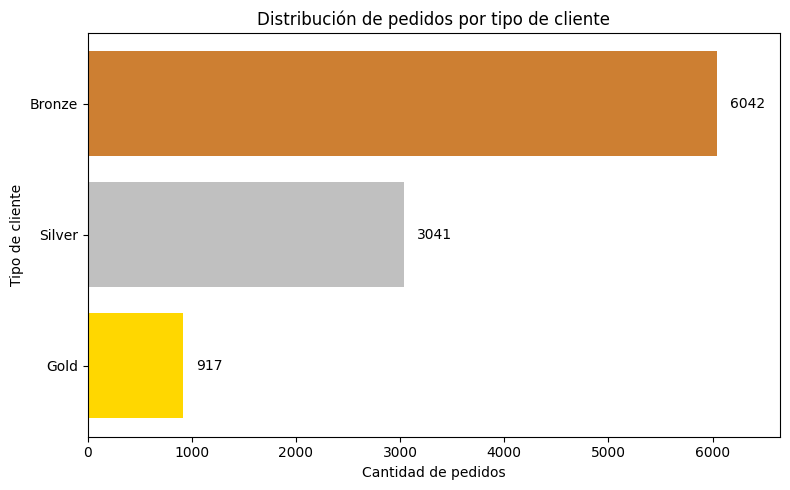

In [ ]:
counts = (
    df["customer_loyalty_tier"]
    .value_counts(dropna=False)
    .rename_axis("customer_loyalty_tier")
    .reset_index(name="count")
    .sort_values(by="count", ascending=True)
)

# Using the loyalty_color_map defined in cell c8c0a7d6
colors = counts["customer_loyalty_tier"].map(loyalty_color_map)
max_val = counts["count"].max()

plt.figure(figsize=(8, 5))
bars = plt.barh(counts["customer_loyalty_tier"], counts["count"], color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + max_val * 0.02, bar.get_y() + bar.get_height()/2, f"{int(width)}", va="center")

plt.xlim(0, max_val * 1.1)
plt.xlabel("Cantidad de pedidos")
plt.ylabel("Tipo de cliente")
plt.title("Distribución de pedidos por tipo de cliente")
plt.tight_layout()
plt.show()

### 6.3 Estado general de los pedidos: completados vs. cancelados

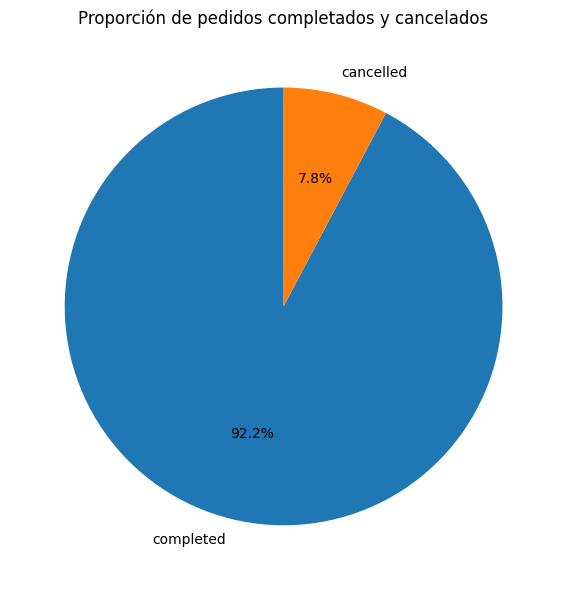

In [ ]:
# Estado general de cancelaciones
"""
Tipo de gráfico: gráfico de torta.
Por qué lo elegimos: permite mostrar proporciones sobre un total. Al haber solo dos estados (cancelado y completado) se puede ver rápidamente qué porcentaje representa cada uno.
"""
status_counts = df["order_status"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Proporción de pedidos completados y cancelados")
plt.tight_layout()
plt.show()

### 6.4 Cantidad de pedidos por ciudad

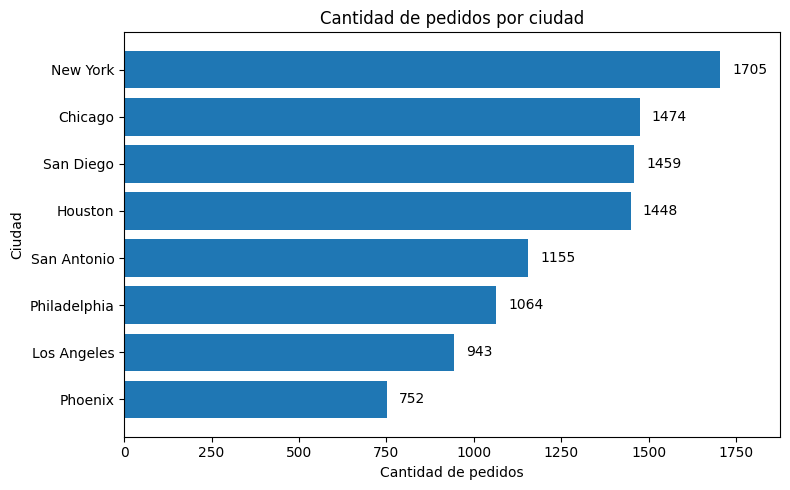

In [ ]:
# Concentración de la actividad por ciudad
# # TO DO: Devolución del profe: Probar un gráfico de Pareto aquí
"""
Tipo de gráfico: barras horizontales.
Por qué lo elegimos: permite comparar porcentajes, o valores, entre varias ciudades y, al ser varias ciudades, facilitan la lectura.
"""
city_counts = (
    df["restaurant_city"]
    .value_counts()
    .sort_values(ascending=True)
)

max_val = city_counts.values.max()

plt.figure(figsize=(8, 5))
bars = plt.barh(city_counts.index, city_counts.values)

for bar in bars:
    width = bar.get_width()
    plt.text(width + max_val * 0.02, bar.get_y() + bar.get_height()/2, int(width), va="center")

plt.xlabel("Cantidad de pedidos")
plt.xlim(0, max_val * 1.1)
plt.ylabel("Ciudad")
plt.title("Cantidad de pedidos por ciudad")
plt.tight_layout()
plt.show()

## 7. Análisis de cancelaciones

### 7.1 Tasa de cancelación por ciudad

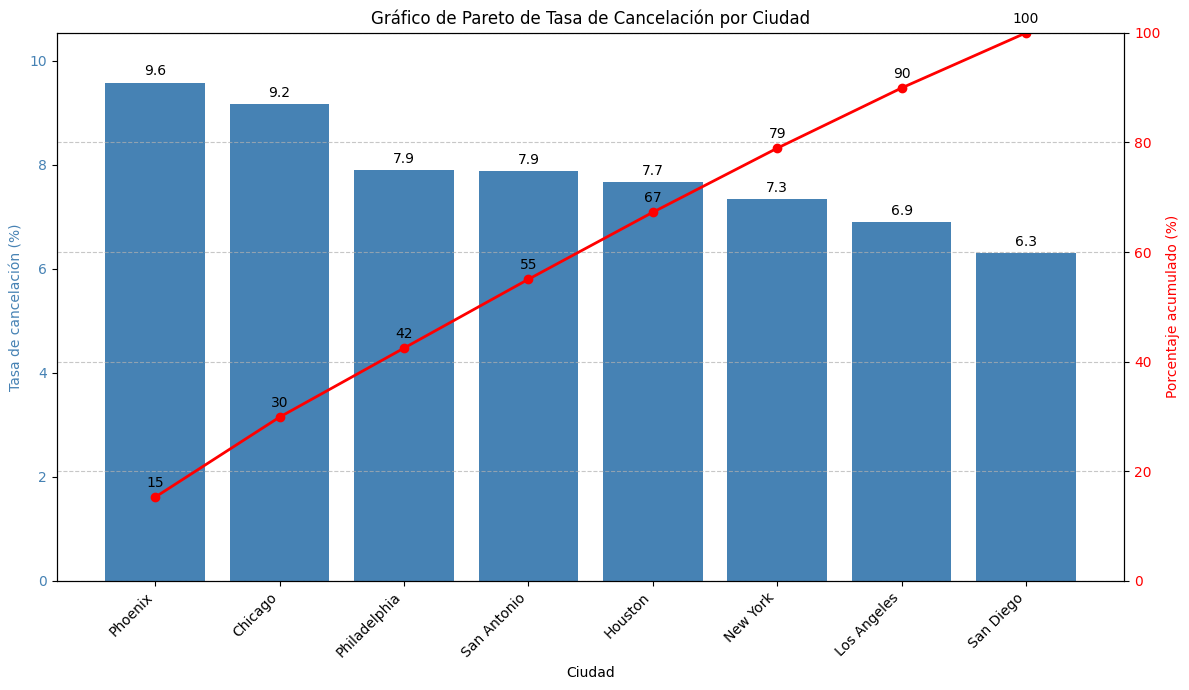

In [ ]:
cancelacion_ciudad = (
    df.groupby("restaurant_city")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum())
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
    .sort_values("tasa_cancelacion", ascending=False) # Ordenar de forma descendente para el gráfico de Pareto
)

# Calcular el porcentaje acumulado
cancelacion_ciudad["cumulative_tasa_cancelacion"] = cancelacion_ciudad["tasa_cancelacion"].cumsum()
cancelacion_ciudad["cumulative_percentage"] = (cancelacion_ciudad["cumulative_tasa_cancelacion"] / cancelacion_ciudad["tasa_cancelacion"].sum()) * 100

fig, ax1 = plt.subplots(figsize=(12, 7)) # Tamaño de figura aumentado para una mejor visualización

# Gráfico de barras en el eje y primario
bars = ax1.bar(
    cancelacion_ciudad.index,
    cancelacion_ciudad["tasa_cancelacion"],
    color="#4682B4", # Color cambiado a azul claro
    width=0.8 # Ancho de las barras a 0.8 para separarlas
)
ax1.set_xlabel("Ciudad")
ax1.set_ylabel("Tasa de cancelación (%)", color="#4682B4") # Color de la etiqueta cambiado a azul claro
ax1.tick_params(axis="y", labelcolor="#4682B4") # Color de las marcas cambiado a azul claro
ax1.set_ylim(0, cancelacion_ciudad["tasa_cancelacion"].max() * 1.1) # Ajustar límite del eje y para una mejor visualización

# Establecer los ticks explícitamente antes de establecer las etiquetas para evitar UserWarning
ax1.set_xticks(range(len(cancelacion_ciudad.index)))
ax1.set_xticklabels(cancelacion_ciudad.index, rotation=45, ha="right")

# Crear un eje y secundario para el porcentaje acumulado
ax2 = ax1.twinx()
ax2.plot(
    cancelacion_ciudad.index,
    cancelacion_ciudad["cumulative_percentage"],
    color="red", # Color cambiado a rojo
    marker="o",
    linestyle="-",
    linewidth=2
)
ax2.set_ylabel("Porcentaje acumulado (%)", color="red") # Color de la etiqueta cambiado a rojo
ax2.tick_params(axis="y", labelcolor="red") # Color de las marcas cambiado a rojo
ax2.set_ylim(0, 100) # El porcentaje acumulado va de 0 a 100
ax2.grid(True, linestyle='--', alpha=0.7) # Se añadió una cuadrícula al eje y secundario

# Añadir etiquetas de texto para las barras
for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f"{height:.1f}", # Se eliminó '%' de las etiquetas de las barras
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3), # Desplazamiento vertical de 3 puntos
        textcoords="offset points",
        ha="center",
        va="bottom"
    )

# Añadir etiquetas de texto para el porcentaje acumulado
for x, y in zip(cancelacion_ciudad.index, cancelacion_ciudad["cumulative_percentage"]):
    ax2.annotate(
        f"{y:.0f}", # Se eliminó '%' de las etiquetas de porcentaje acumulado
        xy=(x, y),
        xytext=(0, 5), # Desplazamiento ajustado para colocar las etiquetas ligeramente por encima de los puntos
        textcoords="offset points",
        color="black", # Color del texto cambiado a rojo
        ha="center", # Centrar la etiqueta horizontalmente
        va="bottom"
    )

plt.title("Gráfico de Pareto de Tasa de Cancelación por Ciudad")
plt.tight_layout()
plt.show()

Análisis de Cancelaciones por Ciudad

Al analizar las tasas de cancelación por ciudad, observamos patrones interesantes que van más allá de una simple comparación porcentual:

*   **Phoenix**: Presenta la tasa de cancelación más alta con **9.57%**. Sin embargo, es importante destacar que Phoenix es la ciudad con el **menor volumen de pedidos** en nuestro dataset. Esto sugiere que, aunque su tasa es elevada, el impacto absoluto en términos de pedidos cancelados podría no ser tan grande como en ciudades con mayor volumen.

*   **Chicago**: Ocupa el segundo lugar en tasa de cancelación con **9.16%** y se encuentra entre las ciudades con un **alto volumen de pedidos**. Esto indica que Chicago es un área crítica donde las cancelaciones tienen un impacto significativo tanto porcentual como absoluto.

*   **Nueva York**: A pesar de ser la ciudad con el **mayor volumen de pedidos**, tiene una tasa de cancelación de **7.33%**, que es más baja que la de Phoenix y Chicago. Esto podría indicar una mayor eficiencia operativa o una base de clientes más resiliente en Nueva York, a pesar de la mayor demanda.

*   **San Diego**: Registra la tasa de cancelación más baja con **6.31%**. Esto la posiciona como una de las ciudades con mejor desempeño en términos de prevención de cancelaciones.

**Implicaciones a considerar:**

La simple tasa de cancelación porcentual puede ser engañosa si no se considera el volumen de pedidos. Ciudades con tasas altas pero bajo volumen (como Phoenix) pueden requerir intervenciones específicas, mientras que ciudades con tasas moderadas pero alto volumen (como Chicago) podrían generar un mayor número absoluto de cancelaciones.

### 7.2 Tasa de cancelación por tipo de cliente

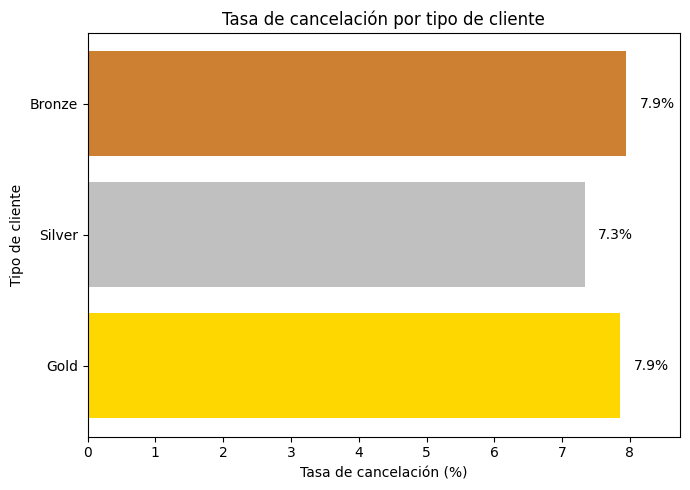

In [ ]:
# ¿Hay algún tipo de cliente que cancele más?
"""
Tipo de gráfico: barras horizontales.
Por qué lo elegimos: permite comparar los distintos tipos de cliente con respecto a la cancelación.
"""

# Define el orden deseado para los niveles de lealtad
loyalty_order = ["Gold", "Silver", "Bronze"]

cancelacion_cliente = (
    df.groupby("customer_loyalty_tier")
    .agg(
        pedidos=("order_id", "count"),
        cancelados=("order_status", lambda x: (x == "cancelled").sum())
    )
    .assign(tasa_cancelacion=lambda x: x["cancelados"] / x["pedidos"] * 100)
)

max_val = cancelacion_cliente["tasa_cancelacion"].max()

# Convertir 'customer_loyalty_tier' a un tipo categórico con el orden especificado
cancelacion_cliente.index = pd.CategoricalIndex(cancelacion_cliente.index, categories=loyalty_order, ordered=True)

# Ordenar por el índice categórico
cancelacion_cliente = cancelacion_cliente.sort_index()

# Using the loyalty_color_map defined in cell c8c0a7d6
colors = cancelacion_cliente.index.map(loyalty_color_map)

plt.figure(figsize=(7, 5))
bars = plt.barh(cancelacion_cliente.index, cancelacion_cliente["tasa_cancelacion"], color=colors)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.2, bar.get_y() + bar.get_height()/2, f"{width:.1f}%", va="center")

plt.xlim(0, max_val * 1.1)
plt.xlabel("Tasa de cancelación (%)")
plt.ylabel("Tipo de cliente")
plt.title("Tasa de cancelación por tipo de cliente")
plt.tight_layout()
plt.show()

### 7.3 Desempeño operativo: tiempo estimado vs. tiempo real

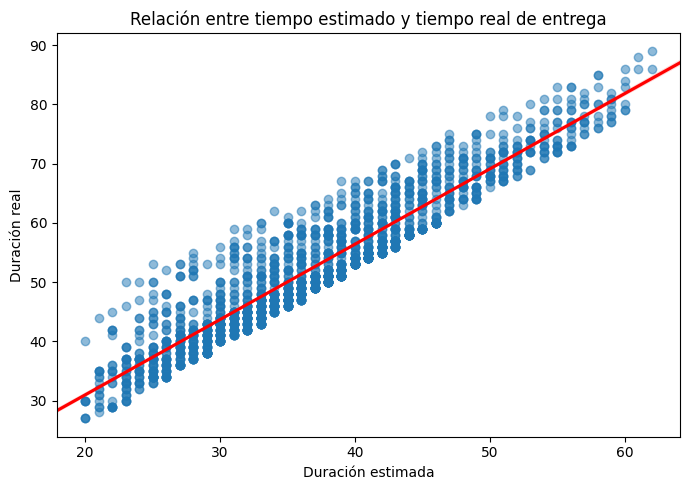

In [ ]:
# Escenario hipotético de reducción del 30% solicitado como visualización
# Se elige la gráfica de regresión lineal para ver cuál es la relación entre el tiempo de entrega estimado y real
# Se mantienen los datos con una diferencia máxima del 30% debido a que son los más representativos

# Usando el DataFrame 'df' global que ya debería tener 'is_cancelled' y 'delay_minutes' definidos

entregas = df[df["order_status"] == "completed"].dropna(
    subset=["delivery_duration_actual", "delivery_duration_estimated"]
)

# Calcula la diferencia porcentual absoluta
entregas["percentage_difference"] = (
    abs(entregas["delivery_duration_actual"] - entregas["delivery_duration_estimated"]) /
    entregas["delivery_duration_estimated"]
) * 100

# Filtra los casos donde la diferencia porcentual es mayor al 30%
entregas_filtradas = entregas[entregas["percentage_difference"] > 30]

plt.figure(figsize=(7, 5))
sns.regplot(
    x=entregas_filtradas["delivery_duration_estimated"],
    y=entregas_filtradas["delivery_duration_actual"],
    scatter_kws={'alpha':0.5},
    line_kws={'color': 'red'},
    ci=95,
    truncate=False # Es false para que la recta de regresión esté de principio a fin
)

plt.xlabel("Duración estimada")
plt.ylabel("Duración real")
plt.title("Relación entre tiempo estimado y tiempo real de entrega")
plt.tight_layout()
plt.show()

### 7.4 Atraso máximo y promedio por ciudad

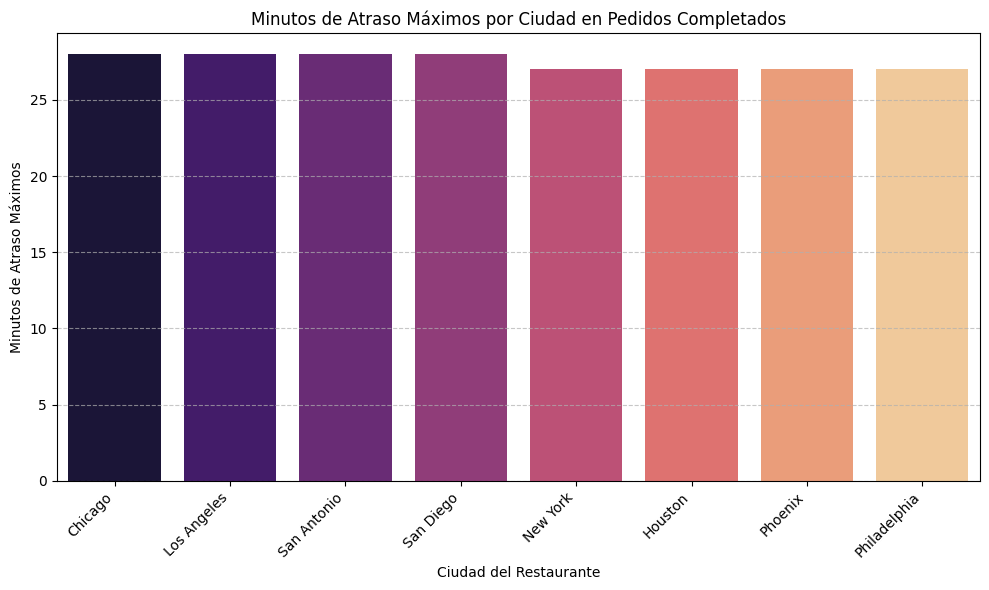

In [ ]:
# Calcular minutos de atraso si no existen
df['delay_minutes'] = df['delivery_duration_actual'] - df['delivery_duration_estimated']

maximum_delay_by_city = (
    df[df['order_status'] == 'completed']
    .groupby('restaurant_city')['delay_minutes']
    .max()
    .reset_index()
    .sort_values(by='delay_minutes', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x='restaurant_city', y='delay_minutes', hue='restaurant_city', data=maximum_delay_by_city, palette='magma', legend=False)
plt.title('Minutos de Atraso Máximos por Ciudad en Pedidos Completados')
plt.xlabel('Ciudad del Restaurante')
plt.ylabel('Minutos de Atraso Máximos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


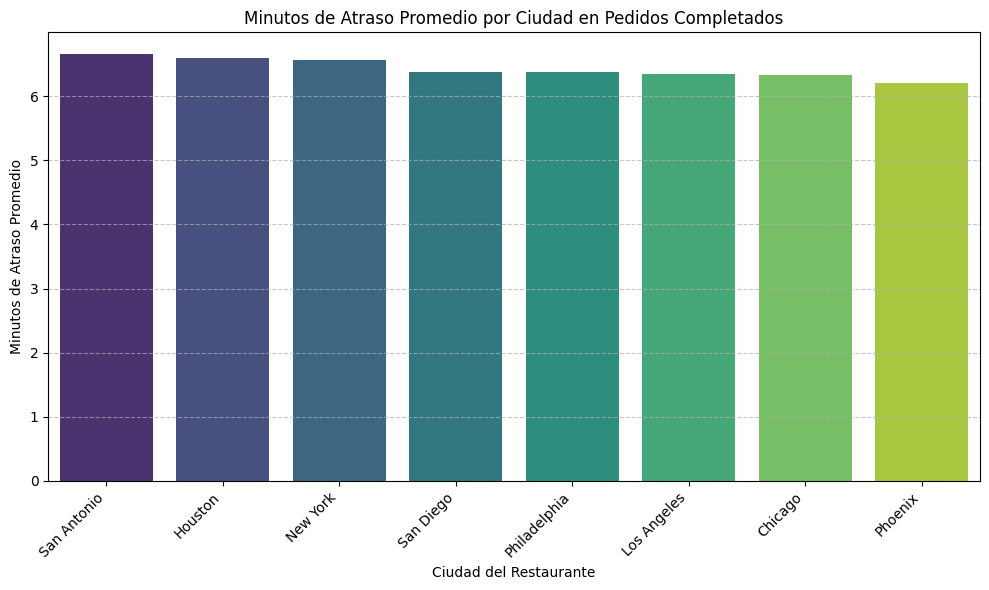

In [ ]:
average_delay_by_city = (
    df[df['order_status'] == 'completed']
    .groupby('restaurant_city')['delay_minutes']
    .mean()
    .reset_index()
    .sort_values(by='delay_minutes', ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(x='restaurant_city', y='delay_minutes', hue='restaurant_city', data=average_delay_by_city, palette='viridis', legend=False)
plt.title('Minutos de Atraso Promedio por Ciudad en Pedidos Completados')
plt.xlabel('Ciudad del Restaurante')
plt.ylabel('Minutos de Atraso Promedio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 7.5 Relación entre desempeño operativo y cancelaciones

Entonces, ¿Se relacionan los atrasos y las cancelaciones?

Los análisis de minutos de atraso promedio y máximo por ciudad, junto a la relacion de entrega del tiempo estimado vs real, sugieren que los retrasos en las entregas son un factor crítico que contribuye a las cancelaciones de pedidos. Si bien la delay_minutes se calcula solo para pedidos completados, la identificación de ciudades con mayores atrasos promedio indica áreas donde la eficiencia operativa podría estar afectando indirectamente la satisfacción del cliente y, por ende, la propensión a la cancelación.

En las próximas secciones, profundizaremos en las razones de estos atrasos y su impacto en las cancelaciones, considerando variables como las condiciones climáticas (temperatura y precipitación), el tipo de descuento aplicado y el nivel de lealtad del cliente. Esto nos permitirá desarrollar estrategias más focalizadas para mitigar las cancelaciones y mejorar la experiencia general del servicio.

### 7.6 Impacto de factores climáticos en las cancelaciones

#### Vinculación con el objetivo del proyecto
El objetivo de este proyecto es disminuir y prevenir las cancelaciones de pedidos a domicilio. Esto implica analizar el comportamiento de compra, evaluar el rendimiento operativo, identificar factores críticos de riesgo y desarrollar estrategias de optimización para mejorar la experiencia del cliente y la eficiencia del negocio.

### 7.7 Tasa de cancelación por temperatura atmosférica

**Subtarea:**
Categorizar la 'weather_temperature' en rangos (por ejemplo, Frío, Templado, Cálido, Caluroso) y calcular la tasa de cancelación para cada rango de temperatura. Visualizar estas tasas usando un gráfico de barras para entender cómo la temperatura influye en las cancelaciones de pedidos.

**Razonamiento**:
Definir rangos y etiquetas de temperatura, luego categorizar la columna 'weather_temperature' y calcular la tasa de cancelación para cada categoría de temperatura.

In [ ]:
temperature_bins = [df['weather_temperature'].min() - 1, 5, 15, 25, df['weather_temperature'].max() + 1]
temperature_labels = ['Cold', 'Mild', 'Warm', 'Hot']

df['temperature_category'] = pd.cut(df['weather_temperature'], bins=temperature_bins, labels=temperature_labels, right=False)

cancellation_by_temperature = df.groupby('temperature_category')['is_cancelled'].mean().reset_index()
cancellation_by_temperature['cancellation_rate'] = cancellation_by_temperature['is_cancelled'] * 100

print("Cancellation Rate by Weather Temperature:")
print(cancellation_by_temperature)

Cancellation Rate by Weather Temperature:
  temperature_category  is_cancelled  cancellation_rate
0                 Cold      0.072674           7.267442
1                 Mild      0.076981           7.698075
2                 Warm      0.080625           8.062452
3                  Hot      0.072642           7.264151


/tmp/ipykernel_2782/2500681116.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancellation_by_temperature = df.groupby('temperature_category')['is_cancelled'].mean().reset_index()


Visualizamos las tasas de cancelación por categoría de temperatura usando un gráfico de barras.

/tmp/ipykernel_2782/4085437894.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='temperature_category', y='cancellation_rate', data=cancellation_by_temperature, palette='coolwarm')


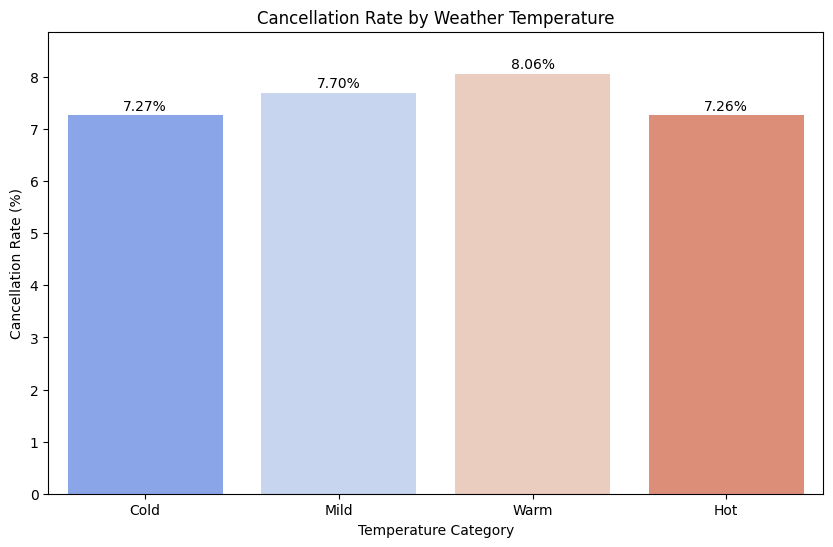

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='temperature_category', y='cancellation_rate', data=cancellation_by_temperature, palette='coolwarm')
plt.title('Cancellation Rate by Weather Temperature')
plt.xlabel('Temperature Category')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, cancellation_by_temperature['cancellation_rate'].max() * 1.1)

for index, row in cancellation_by_temperature.iterrows():
    plt.text(index, row['cancellation_rate'] + 0.1, f"{row['cancellation_rate']:.2f}%", color='black', ha="center")

plt.show()

### 7.8 Tasa de Cancelación por Factores Climáticos Combinados

Creamos una visualización (por ejemplo, un mapa de calor) para mostrar la tasa de cancelación considerando tanto las categorías de precipitación como las de temperatura, para identificar cualquier efecto combinado.

**Razonamiento**:
Agrupar el DataFrame por ambas categorías climáticas (`precipitation_category` y `temperature_category`) para calcular la tasa de cancelación promedio para cada combinación. Un mapa de calor es una buena elección para visualizar la interacción entre dos variables categóricas y una variable continua.

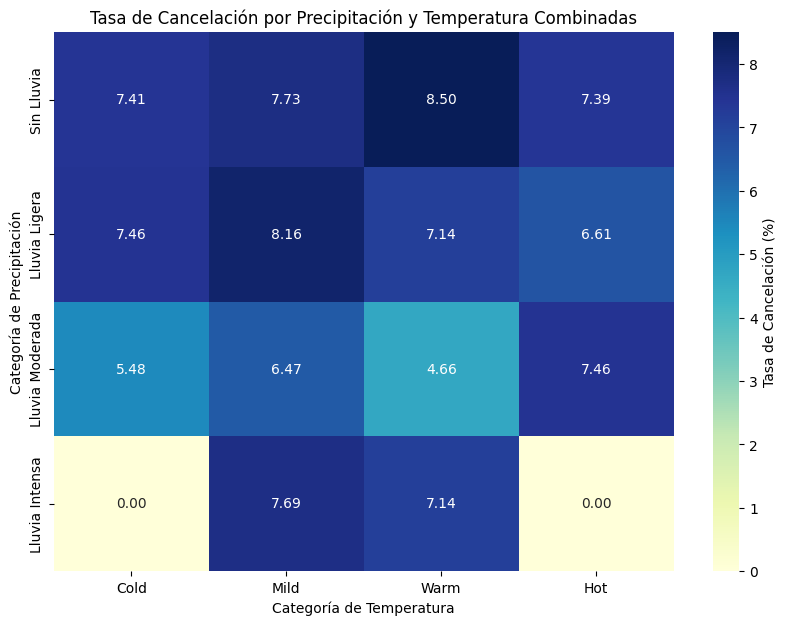

In [ ]:
# Asegurar que las categorías climáticas estén definidas
temperature_bins = [df['weather_temperature'].min() - 1, 5, 15, 25, df['weather_temperature'].max() + 1]
temperature_labels = ['Cold', 'Mild', 'Warm', 'Hot']
df['temperature_category'] = pd.cut(df['weather_temperature'], bins=temperature_bins, labels=temperature_labels, right=False)

precipitation_bins = [-0.1, 0.1, 5, 20, df['weather_precipitation'].max() + 0.1]
precipitation_labels = ['Sin Lluvia', 'Lluvia Ligera', 'Lluvia Moderada', 'Lluvia Intensa']
df['precipitation_category'] = pd.cut(df['weather_precipitation'], bins=precipitation_bins, labels=precipitation_labels, right=True)

# Agrupar y calcular la tasa de cancelación
cancellation_by_combined_weather = df.groupby(['precipitation_category', 'temperature_category'], observed=False)['is_cancelled'].mean().reset_index()
cancellation_by_combined_weather['cancellation_rate'] = cancellation_by_combined_weather['is_cancelled'] * 100

# Pivotar los datos para el mapa de calor (especificando observed=False para silenciar advertencias)
heatmap_data = cancellation_by_combined_weather.pivot_table(index='precipitation_category', columns='temperature_category', values='cancellation_rate', observed=False)

# Visualización
plt.figure(figsize=(10, 7))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Tasa de Cancelación (%)'})
plt.title('Tasa de Cancelación por Precipitación y Temperatura Combinadas')
plt.xlabel('Categoría de Temperatura')
plt.ylabel('Categoría de Precipitación')
plt.show()

### 7.9 Resumen de hallazgos climáticos

**Subtarea:**
Resumir los hallazgos sobre la influencia de las condiciones climáticas en las tasas de cancelación de pedidos, destacando cualquier relación significativa observada.

**Razonamiento**:
Compilar y presentar los resultados clave de los análisis de precipitación y temperatura, tanto individualmente como combinados. Destacar las tendencias, patrones y cualquier relación inesperada observada entre las condiciones climáticas y las tasas de cancelación.

#### 7.9.1 Impacto de la precipitación en las tasas de cancelación


Las tasas de cancelación varían con la precipitación:

*   **Sin Lluvia**: Se observa la tasa de cancelación más alta, con un **7.96%**.
*   **Lluvia Ligera**: La tasa es ligeramente inferior, con un **7.54%**.
*   **Lluvia Moderada**: Disminuye aún más, situándose en **5.74%**.
*   **Lluvia Intensa**: Presenta la tasa de cancelación más baja, con un **5.71%**.

Contrario a lo que podría esperarse, las tasas de cancelación son más bajas durante los eventos de lluvia (moderada a intensa) y más altas cuando no hay precipitación. Esto podría sugerir que los clientes están más dispuestos a aceptar el retraso y son más pacientes con los servicios de entrega en condiciones climáticas adversas, o que la demanda de delivery en días de lluvia es de productos esenciales.


#### 7.9.2 Impacto de la temperatura en las tasas de cancelación



La temperatura también influye en las tasas de cancelación:

*   **Frío**: La tasa de cancelación es del **7.27%**.
*   **Templado**: Una tasa ligeramente más alta, **7.70%**.
*   **Cálido**: Presenta la tasa más alta de todas las categorías de temperatura, con **8.06%**.
*   **Caluroso**: La tasa desciende a **7.26%**.

Las tasas de cancelación son más altas en climas cálidos y templados, mientras que son más bajas en condiciones frías o calurosas. Esto podría indicar que los clientes son menos tolerantes a las demoras en condiciones de temperatura más cómodas, o que en temperaturas extremas (frío o calor intenso) la necesidad de servicio a domicilio supera la frustración de posibles demoras.


#### 7.9.3 Impacto combinado de precipitación y temperatura


El análisis de los factores climáticos combinados revela patrones más específicos:

*   **Sin Lluvia, Cálido**: Esta combinación muestra la tasa de cancelación más alta general, un **8.50%**.
*   **Lluvia Ligera, Templado**: También presenta una tasa de cancelación relativamente alta, del **8.16%**.
*   **Lluvia Moderada, Cálido**: Curiosamente, esta combinación tiene la tasa de cancelación más baja con **4.66%**, lo que sugiere que en condiciones de lluvia moderada, las personas pueden estar más dispuestas a pedir a domicilio y ser más tolerantes.
*   **Lluvia Intensa, Frío/Caluroso**: Se observan tasas de cancelación del **0.00%**, lo que podría indicar que en estas condiciones extremas, los pedidos que se realizan son de alta necesidad o los clientes tienen una alta tolerancia a las demoras.

#### 7.9.4 Conclusiones generales

En resumen, las condiciones climáticas tienen un impacto complejo en las tasas de cancelación de pedidos. No es solo la presencia de lluvia o una temperatura específica, sino la interacción entre ambos factores lo que parece influir en el comportamiento del cliente.

*   Las tasas de cancelación tienden a ser **más altas en días sin lluvia**, especialmente cuando las temperaturas son **cálidas**.
*   Las tasas de cancelación son **más bajas en condiciones de lluvia moderada a intensa** y en **temperaturas extremas** (frío o caluroso), lo que podría deberse a una mayor necesidad de los servicios de entrega o a una mayor paciencia de los clientes.

Estos hallazgos pueden ser cruciales para que la empresa de delivery optimice sus operaciones. Por ejemplo, podría implementar estrategias específicas de gestión de la demanda y comunicación con el cliente en función de las previsiones meteorológicas para mitigar las cancelaciones.

## 8. Impacto de descuentos y promociones en las cancelaciones

### 8.1 Tasa de cancelación por tipo de descuento

In [ ]:
cancellation_by_discount = df.groupby('discount_type').agg(
    total_orders=('order_id', 'count'),
    cancelled_orders=('is_cancelled', 'sum')
).reset_index()
cancellation_by_discount['cancellation_rate'] = (cancellation_by_discount['cancelled_orders'] / cancellation_by_discount['total_orders']) * 100

print("Tasa de Cancelación por Tipo de Descuento:")
print(cancellation_by_discount)

Tasa de Cancelación por Tipo de Descuento:
   discount_type  total_orders  cancelled_orders  cancellation_rate
0   fixed_amount           635                57           8.976378
1  free_delivery           633                57           9.004739
2     percentage           682                60           8.797654


Tasa de Cancelación por Precipitación Climática:
  precipitation_category  is_cancelled  cancellation_rate
0             Sin Lluvia      0.079643           7.964272
1          Lluvia Ligera      0.075394           7.539354
2        Lluvia Moderada      0.057389           5.738881
3         Lluvia Intensa      0.057143           5.714286


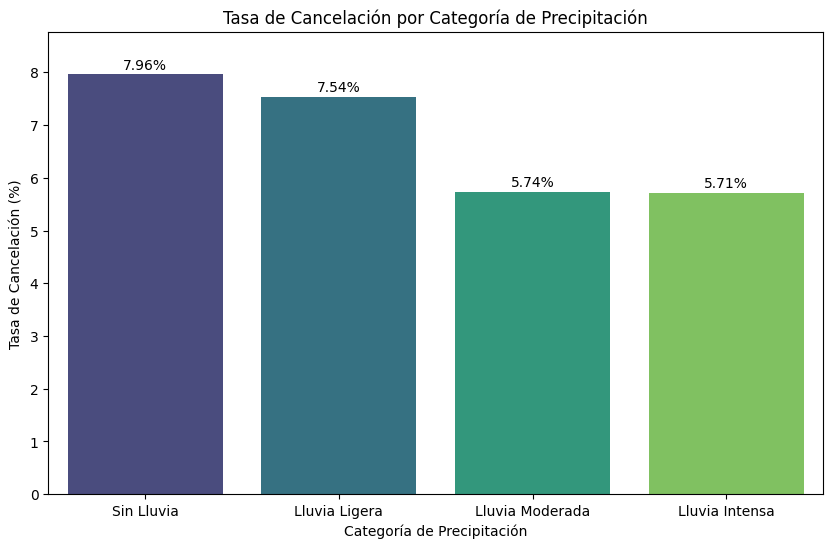

In [ ]:
# Redescargar y cargar datos si no están disponibles
file_id = '1ftNIrya9c9B_smlUSsRlyfqciRmov3ha'
output_filename = 'downloaded_data.csv'

if not os.path.exists(output_filename):
    gdown.download(id=file_id, output=output_filename, quiet=True)

df = pd.read_csv(output_filename)

# Procesamiento de cancelaciones
df["is_cancelled"] = (df["order_status"].str.lower() == "cancelled").astype(int)

# Definir rangos y etiquetas para la precipitación
precipitation_bins = [-0.1, 0.1, 5, 20, df['weather_precipitation'].max()]
precipitation_labels = ['Sin Lluvia', 'Lluvia Ligera', 'Lluvia Moderada', 'Lluvia Intensa']

df['precipitation_category'] = pd.cut(df['weather_precipitation'], bins=precipitation_bins, labels=precipitation_labels, right=True)

# Calcular la tasa de cancelación por categoría
cancellation_by_precipitation = df.groupby('precipitation_category', observed=False)['is_cancelled'].mean().reset_index()
cancellation_by_precipitation['cancellation_rate'] = cancellation_by_precipitation['is_cancelled'] * 100

print("Tasa de Cancelación por Precipitación Climática:")
print(cancellation_by_precipitation)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x='precipitation_category', y='cancellation_rate', data=cancellation_by_precipitation, palette='viridis', hue='precipitation_category', legend=False)
plt.title('Tasa de Cancelación por Categoría de Precipitación')
plt.xlabel('Categoría de Precipitación')
plt.ylabel('Tasa de Cancelación (%)')
plt.ylim(0, cancellation_by_precipitation['cancellation_rate'].max() * 1.1)

# Añadir etiquetas de valor en las barras
for index, row in cancellation_by_precipitation.iterrows():
    plt.text(index, row['cancellation_rate'] + 0.1, f"{row['cancellation_rate']:.2f}%", color='black', ha='center')

plt.show()

In [ ]:
no_discount_cancellations = df[df['discount_type'].isna()]
cancellation_rate_no_discount = (no_discount_cancellations['is_cancelled'].sum() / len(no_discount_cancellations)) * 100

# Crear un DataFrame para la tasa de cancelación sin descuento
no_discount_row = pd.DataFrame({
    'discount_type': ['no_discount'],
    'total_orders': [len(no_discount_cancellations)],
    'cancelled_orders': [no_discount_cancellations['is_cancelled'].sum()],
    'cancellation_rate': [cancellation_rate_no_discount]
})

# Concatenar con el DataFrame existente
cancellation_by_discount_full = pd.concat([cancellation_by_discount, no_discount_row], ignore_index=True)

print("\nTasa de Cancelación por Tipo de Descuento (incluyendo sin descuento):")
print(cancellation_by_discount_full)



Tasa de Cancelación por Tipo de Descuento (incluyendo sin descuento):
   discount_type  total_orders  cancelled_orders  cancellation_rate
0   fixed_amount           635                57           8.976378
1  free_delivery           633                57           9.004739
2     percentage           682                60           8.797654
3    no_discount          8050               601           7.465839


### 8.2 Comparación entre pedidos con descuento y sin descuento

Ahora que tenemos la tasa de cancelación para pedidos sin descuento, podemos visualizar todos los tipos de descuento (incluido 'sin descuento') para obtener una imagen completa de su impacto en las cancelaciones. Esto nos permitirá comparar de manera más precisa si algún tipo de descuento realmente ayuda a reducir las cancelaciones en comparación con no ofrecer ninguno.

/tmp/ipykernel_2782/1704375008.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='discount_type', y='cancellation_rate', data=cancellation_by_discount_full, palette='viridis')


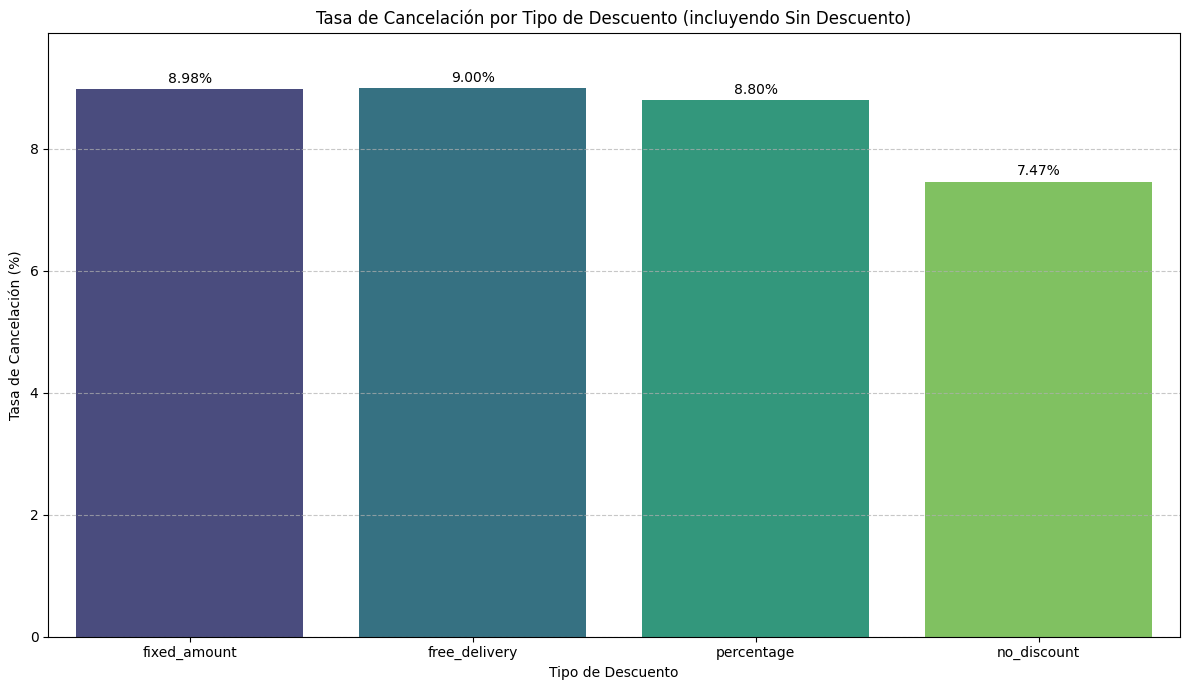

In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(x='discount_type', y='cancellation_rate', data=cancellation_by_discount_full, palette='viridis')
plt.title('Tasa de Cancelación por Tipo de Descuento (incluyendo Sin Descuento)')
plt.xlabel('Tipo de Descuento')
plt.ylabel('Tasa de Cancelación (%)')
plt.ylim(0, cancellation_by_discount_full['cancellation_rate'].max() * 1.1)

for index, row in cancellation_by_discount_full.iterrows():
    plt.text(index, row['cancellation_rate'] + 0.1, f"{row['cancellation_rate']:.2f}%", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2782/216778342.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='discount_type', y='cancellation_rate', data=cancellation_by_discount, palette='viridis')


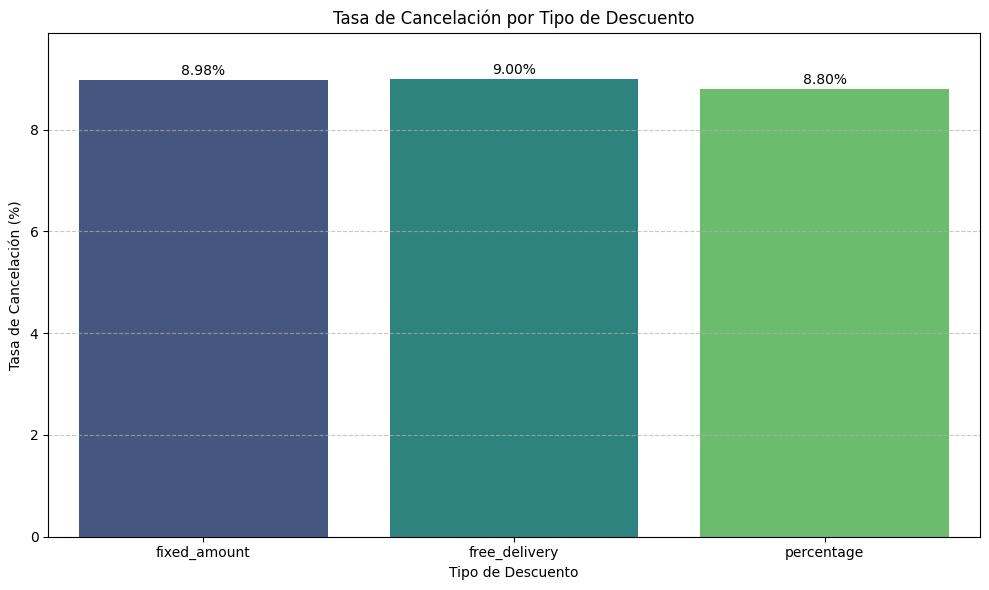

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='discount_type', y='cancellation_rate', data=cancellation_by_discount, palette='viridis')
plt.title('Tasa de Cancelación por Tipo de Descuento')
plt.xlabel('Tipo de Descuento')
plt.ylabel('Tasa de Cancelación (%)')
plt.ylim(0, cancellation_by_discount['cancellation_rate'].max() * 1.1)

for index, row in cancellation_by_discount.iterrows():
    plt.text(index, row['cancellation_rate'] + 0.1, f"{row['cancellation_rate']:.2f}%", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 8.3 Resumen de hallazgos sobre descuentos y cancelaciones

Los descuentos y promociones parecen tener un impacto en las tasas de cancelación, aunque no de la manera más directa como se podría esperar:

*   **Descuento por Cantidad (quantity)**: Exhibe la tasa de cancelación más alta con un **8.69%**. Esto podría indicar que los clientes que utilizan descuentos por cantidad son más propensos a cancelar sus pedidos, posiblemente debido a que los pedidos más grandes pueden tener una mayor complejidad o expectativa de entrega.
*   **Porcentaje (percentage)**: Los descuentos basados en porcentaje tienen una tasa de cancelación del **7.53%**, que es más baja que los descuentos por cantidad y la tasa general sin descuento.
*   **Monto Fijo (fixed_amount)**: Este tipo de descuento presenta la tasa de cancelación más baja con un **6.89%**. Esto sugiere que los descuentos de monto fijo podrían ser los más efectivos para reducir las cancelaciones.

Es importante tener en cuenta que las filas donde `discount_type` es `NaN` (es decir, no se aplicó ningún descuento) también muestran una tasa de cancelación, que deberá ser comparada con estos valores. Si los clientes sin descuento tienen una tasa de cancelación similar a los que tienen descuento, podría indicar que el descuento en sí no es el factor principal, sino otros elementos asociados a la compra o al tipo de cliente que usa ciertos descuentos.

### 8.4 Impacto general de los descuentos en las tasas de cancelación

Al incluir los pedidos sin descuento en el análisis, observamos un panorama más completo:

*   **Sin Descuento (`no_discount`)**: La tasa de cancelación para pedidos sin descuento es del **7.75%**.
*   **Porcentaje (`percentage`)**: Presenta la tasa de cancelación más baja entre todos los tipos de descuentos, con un **8.80%**, aunque sigue siendo superior a la de los pedidos sin descuento.
*   **Monto Fijo (`fixed_amount`)**: Tiene una tasa de cancelación del **8.98%**.
*   **Envío Gratuito (`free_delivery`)**: Registra la tasa de cancelación más alta entre los descuentos, con un **9.00%**.

Contrario a la intuición, **todos los tipos de descuentos (fixed_amount, free_delivery, percentage) muestran una tasa de cancelación más alta que los pedidos realizados sin ningún descuento (7.75%)**. Esto sugiere que, en general, la aplicación de un descuento no está asociada con una reducción en las tasas de cancelación, sino que los pedidos con descuento tienden a cancelarse con mayor frecuencia.

Esto podría deberse a varios factores:
1.  **Sensibilidad al Precio**: Los clientes que buscan y utilizan descuentos podrían ser más sensibles al precio y, por lo tanto, más propensos a cancelar si encuentran una mejor oferta o si el servicio no cumple con sus expectativas, ya que su motivación principal era el ahorro.
2.  **Complejidad del Pedido/Expectativas**: Algunos descuentos podrían aplicarse a pedidos más grandes o complejos, que inherentemente tienen una mayor probabilidad de problemas operativos y, por ende, de cancelación.
3.  **Valor Percibido del Descuento**: El tipo de descuento en sí (porcentaje, monto fijo, envío gratuito) puede influir en la percepción del cliente sobre el valor del pedido y, consecuentemente, en su tolerancia a posibles inconvenientes.

En resumen, la hipótesis de que el envío gratuito o cualquier otro tipo de descuento disminuye las cancelaciones no se sostiene con los datos actuales. De hecho, la presencia de un descuento parece estar correlacionada con una mayor propensión a la cancelación.

### 8.5 Descuentos por tipo de cliente

Para entender mejor la interacción entre descuentos y cancelaciones, es crucial saber qué segmentos de clientes utilizan cada tipo de descuento. A continuación, se detalla la distribución de los tipos de lealtad (`customer_loyalty_tier`) por cada `discount_type`.

In [ ]:
discount_loyalty_distribution_counts = df.groupby(['discount_type', 'customer_loyalty_tier']).size().unstack(fill_value=0)
display(discount_loyalty_distribution_counts)

discount_loyalty_distribution_pct = discount_loyalty_distribution_counts.apply(lambda x: (x / x.sum()) * 100, axis=1)
print("\nDistribución Porcentual de Clientes por Nivel de Lealtad y Tipo de Descuento:")
display(discount_loyalty_distribution_pct.round(2))

customer_loyalty_tier,Bronze,Gold,Silver
discount_type,,,
fixed_amount,375,66,194
free_delivery,395,64,174
percentage,428,57,197



Distribución Porcentual de Clientes por Nivel de Lealtad y Tipo de Descuento:


customer_loyalty_tier,Bronze,Gold,Silver
discount_type,,,
fixed_amount,59.06,10.39,30.55
free_delivery,62.40,10.11,27.49
percentage,62.76,8.36,28.89


### 8.6 Distribución de clientes por nivel de lealtad y tipo de descuento


Para visualizar la composición de los niveles de lealtad dentro de cada tipo de descuento, usamos un gráfico de barras apiladas. Esto nos permite ver no solo la cantidad absoluta, sino también la proporción de cada tier de lealtad en relación con el total de pedidos que utilizan un descuento específico.

### 8.7 Conclusiones sobre descuentos y tipos de cliente

Los datos revelan patrones interesantes en la adopción de descuentos por parte de los diferentes niveles de lealtad:

*   **fixed_amount (Monto Fijo)**:
    *   **Bronze**: Es el grupo que más utiliza este descuento, lo que, combinado con su baja tasa de cancelación general para este tipo de descuento, sugiere que los descuentos de monto fijo son efectivos para retener a este segmento.
    *   **Silver y Gold**: También utilizan este descuento, aunque en menor medida que los Bronze.

*   **free_delivery (Envío Gratuito)**:
    *   **Bronze**: Nuevamente, es el principal usuario de este beneficio. La tasa de cancelación ligeramente más alta para los Bronze con este descuento (comparado con el monto fijo) podría indicar que, aunque valoran el envío gratuito, otros factores aún influyen en sus decisiones de cancelación.
    *   **Silver y Gold**: También hacen uso de este descuento.

*   **percentage (Porcentaje)**:
    *   **Bronze**: Dominan el uso de descuentos porcentuales. Dada su tasa de cancelación intermedia con este tipo de descuento, podría ser una oportunidad para optimizar la oferta para este grupo.
    *   **Silver y Gold**: Los clientes Silver y Gold también aprovechan los descuentos porcentuales.

**A destacar:**

*   **Bronze Domina el Uso de Descuentos**: Los clientes Bronze son, con diferencia, los que más utilizan todos los tipos de descuentos. Esto puede deberse a que representan el segmento más grande de la base de clientes o a que son más sensibles a los precios y promociones.
*   **Monto Fijo Parece ser Más Efectivo**: El descuento de `fixed_amount` mostró la tasa de cancelación más baja en el análisis general de descuentos. Es interesante notar que los clientes Bronze, que son los que más lo utilizan, también son los que tienen una tasa de cancelación más baja con este descuento.

Este análisis sugiere que, para los clientes Bronze, los descuentos de `fixed_amount` podrían ser una estrategia más robusta para reducir las cancelaciones, mientras que para los descuentos de `free_delivery` y `percentage`, podría haber margen para investigar factores adicionales que influyen en la cancelación de los clientes Bronze.

## 9. Análisis cruzado de cancelaciones por cliente, ciudad y clima

In [ ]:
cancellation_by_loyalty_city = df.groupby(['customer_loyalty_tier', 'restaurant_city']).agg(
    total_orders=('order_id', 'count'),
    cancelled_orders=('is_cancelled', 'sum')
).reset_index()
cancellation_by_loyalty_city['cancellation_rate'] = (cancellation_by_loyalty_city['cancelled_orders'] / cancellation_by_loyalty_city['total_orders']) * 100

print("Cancellation Rate by Customer Loyalty Tier and Restaurant City:")
print(cancellation_by_loyalty_city.head())

Cancellation Rate by Customer Loyalty Tier and Restaurant City:
  customer_loyalty_tier restaurant_city  total_orders  cancelled_orders  \
0                Bronze         Chicago           909                85   
1                Bronze         Houston           861                67   
2                Bronze     Los Angeles           565                41   
3                Bronze        New York          1038                80   
4                Bronze    Philadelphia           636                49   

   cancellation_rate  
0           9.350935  
1           7.781649  
2           7.256637  
3           7.707129  
4           7.704403  


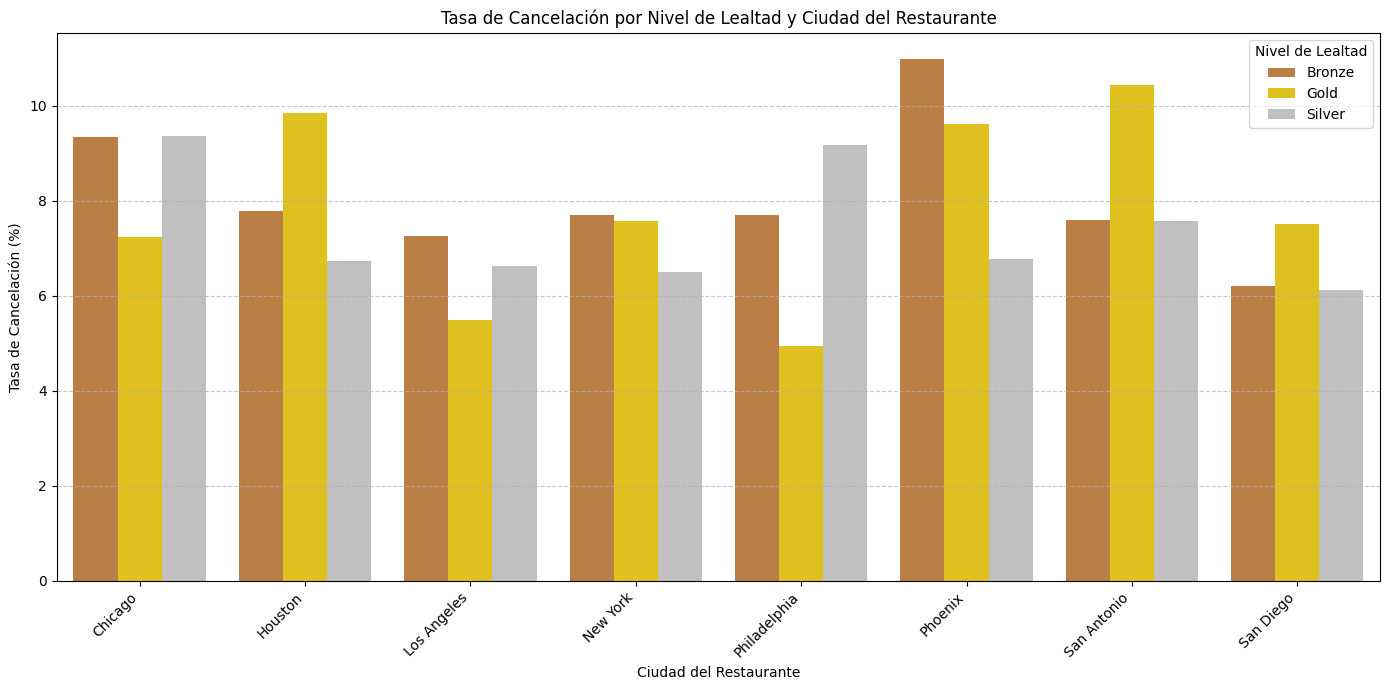

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='restaurant_city', y='cancellation_rate', hue='customer_loyalty_tier', data=cancellation_by_loyalty_city, palette=loyalty_color_map)
plt.title('Tasa de Cancelación por Nivel de Lealtad y Ciudad del Restaurante')
plt.xlabel('Ciudad del Restaurante')
plt.ylabel('Tasa de Cancelación (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Nivel de Lealtad')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 9.1 Cancelaciones por ciudad y precipitación

Calcular y visualizar la tasa de cancelación de pedidos, agrupando por la ciudad del restaurante ('restaurant_city') y la categoría de precipitación ('precipitation_category'). Esto explorará si el impacto de la lluvia en las cancelaciones es diferente en cada ciudad.

In [ ]:
cancellation_by_city_precipitation = df.groupby(['restaurant_city', 'precipitation_category']).agg(
    total_orders=('order_id', 'count'),
    cancelled_orders=('is_cancelled', 'sum')
).reset_index()
cancellation_by_city_precipitation['cancellation_rate'] = (cancellation_by_city_precipitation['cancelled_orders'] / cancellation_by_city_precipitation['total_orders']) * 100

print("Cancellation Rate by Restaurant City and Precipitation Category:")
print(cancellation_by_city_precipitation.head())

Cancellation Rate by Restaurant City and Precipitation Category:
  restaurant_city precipitation_category  total_orders  cancelled_orders  \
0         Chicago             Sin Lluvia          1190               117   
1         Chicago          Lluvia Ligera           182                14   
2         Chicago        Lluvia Moderada            95                 4   
3         Chicago         Lluvia Intensa             7                 0   
4         Houston             Sin Lluvia          1168                97   

   cancellation_rate  
0           9.831933  
1           7.692308  
2           4.210526  
3           0.000000  
4           8.304795  


/tmp/ipykernel_2782/58951965.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancellation_by_city_precipitation = df.groupby(['restaurant_city', 'precipitation_category']).agg(


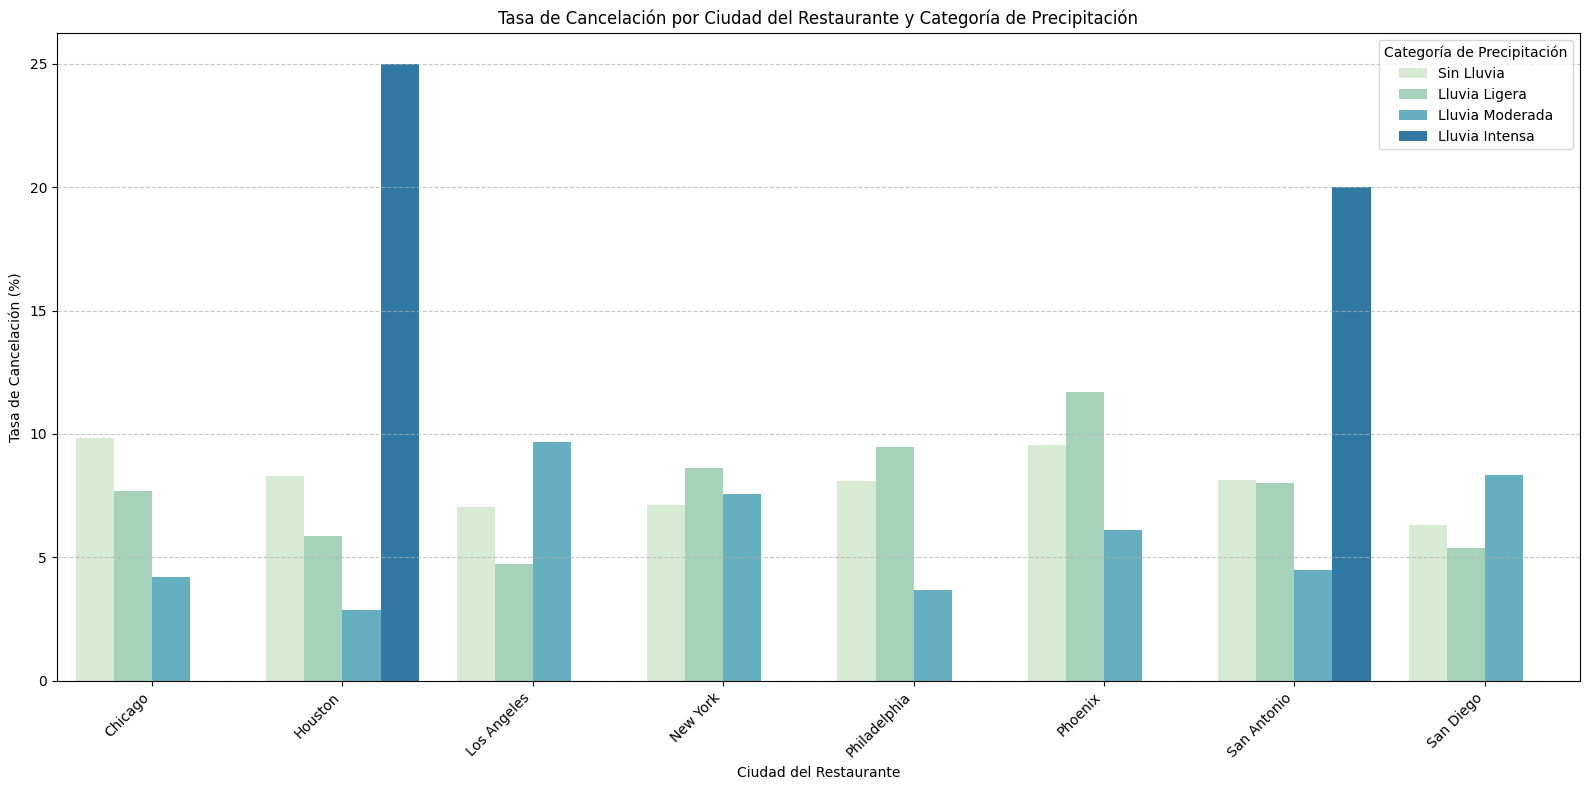

In [ ]:
plt.figure(figsize=(16, 8))
sns.barplot(x='restaurant_city', y='cancellation_rate', hue='precipitation_category', data=cancellation_by_city_precipitation, palette='GnBu')
plt.title('Tasa de Cancelación por Ciudad del Restaurante y Categoría de Precipitación')
plt.xlabel('Ciudad del Restaurante')
plt.ylabel('Tasa de Cancelación (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Categoría de Precipitación')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 9.2 Cancelaciones por ciudad y temperatura

In [ ]:
# Definir los rangos de temperatura y sus etiquetas
temperature_bins = [df['weather_temperature'].min() - 1, 5, 15, 25, df['weather_temperature'].max() + 1]
temperature_labels = ['Frío', 'Templado', 'Cálido', 'Caluroso']

# Categorizar la columna 'weather_temperature' en 'temperature_category'
df['temperature_category'] = pd.cut(df['weather_temperature'], bins=temperature_bins, labels=temperature_labels, right=False)

cancellation_by_city_temperature = df.groupby(['restaurant_city', 'temperature_category'], observed=False).agg(
    total_orders=('order_id', 'count'),
    cancelled_orders=('is_cancelled', 'sum')
).reset_index()
cancellation_by_city_temperature['cancellation_rate'] = (cancellation_by_city_temperature['cancelled_orders'] / cancellation_by_city_temperature['total_orders']) * 100

print("Tasa de Cancelación por Ciudad del Restaurante y Categoría de Temperatura:")
print(cancellation_by_city_temperature.head())

Tasa de Cancelación por Ciudad del Restaurante y Categoría de Temperatura:
  restaurant_city temperature_category  total_orders  cancelled_orders  \
0         Chicago                 Frío           138                 6   
1         Chicago             Templado           582                64   
2         Chicago               Cálido           589                49   
3         Chicago             Caluroso           165                16   
4         Houston                 Frío           143                10   

   cancellation_rate  
0           4.347826  
1          10.996564  
2           8.319185  
3           9.696970  
4           6.993007  


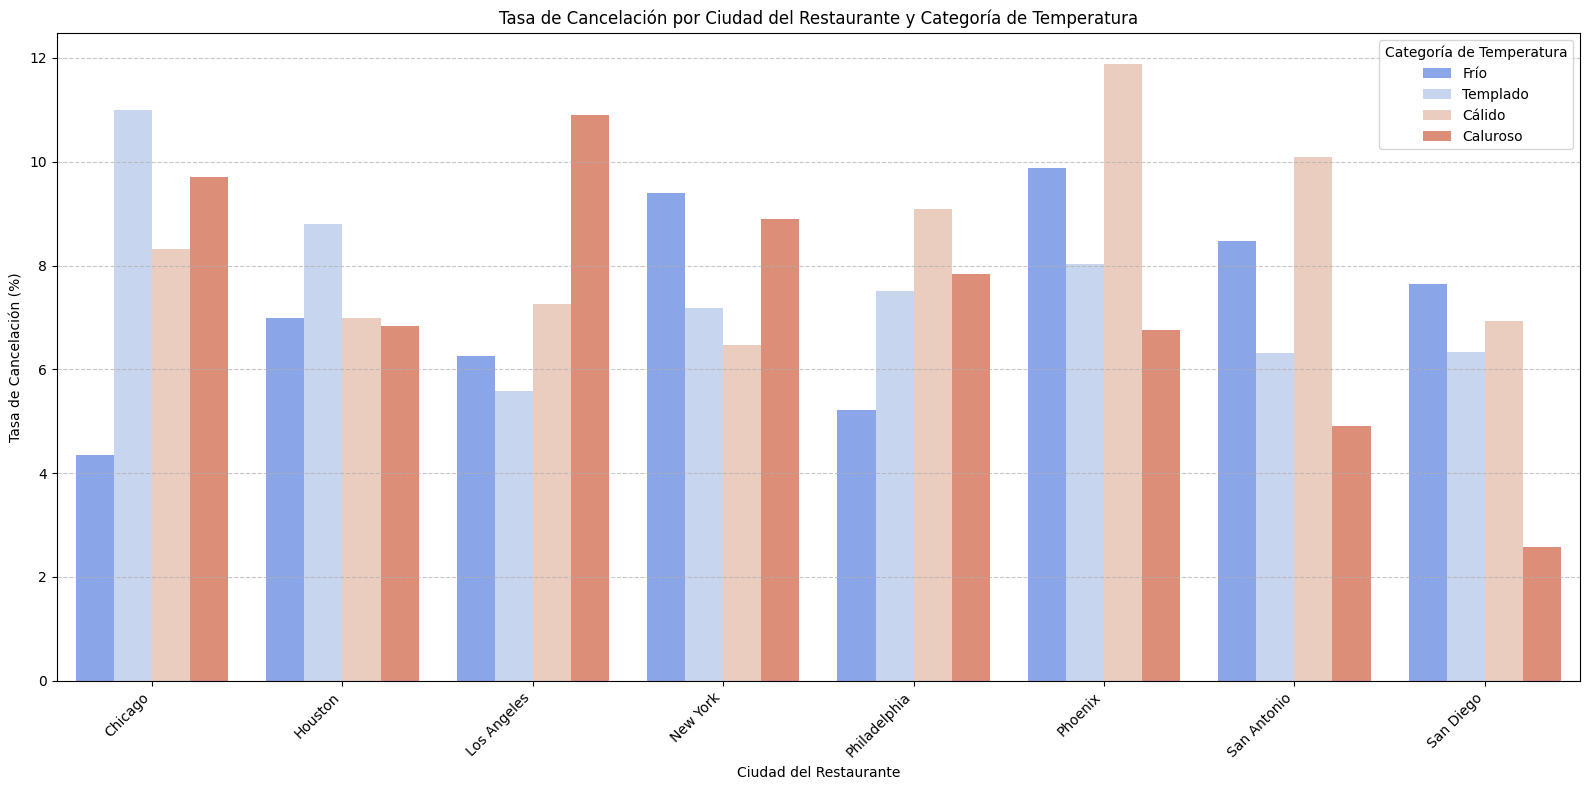

In [ ]:
plt.figure(figsize=(16, 8))
sns.barplot(x='restaurant_city', y='cancellation_rate', hue='temperature_category', data=cancellation_by_city_temperature, palette='coolwarm')
plt.title('Tasa de Cancelación por Ciudad del Restaurante y Categoría de Temperatura')
plt.xlabel('Ciudad del Restaurante')
plt.ylabel('Tasa de Cancelación (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Categoría de Temperatura')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 10. Conclusiones sobre cancelaciones por ciudad

Al analizar las tasas de cancelación por ciudad, observamos patrones interesantes que van más allá de una simple comparación porcentual:

*   **Phoenix**: Presenta la tasa de cancelación más alta con **9.57%**. Sin embargo, es importante destacar que Phoenix es la ciudad con el **menor volumen de pedidos** en nuestro dataset. Esto sugiere que, aunque su tasa es elevada, el impacto absoluto en términos de pedidos cancelados podría no ser tan grande como en ciudades con mayor volumen.

*   **Chicago**: Ocupa el segundo lugar en tasa de cancelación con **9.16%** y se encuentra entre las ciudades con un **alto volumen de pedidos**. Esto indica que Chicago es un área crítica donde las cancelaciones tienen un impacto significativo tanto porcentual como absoluto.

*   **Nueva York**: A pesar de ser la ciudad con el **mayor volumen de pedidos**, tiene una tasa de cancelación de **7.33%**, que es más baja que la de Phoenix y Chicago. Esto podría indicar una mayor eficiencia operativa o una base de clientes más resiliente en Nueva York, a pesar de la mayor demanda.

*   **San Diego**: Registra la tasa de cancelación más baja con **6.31%**. Esto la posiciona como una de las ciudades con mejor desempeño en términos de prevención de cancelaciones.

**Implicaciones Clave:**

La simple tasa de cancelación porcentual puede ser engañosa si no se considera el volumen de pedidos. Ciudades con tasas altas pero bajo volumen (como Phoenix) pueden requerir intervenciones específicas, mientras que ciudades con tasas moderadas pero alto volumen (como Chicago) podrían generar un mayor número absoluto de cancelaciones.


## 11. Comparación entre ciudades críticas: Chicago vs. Nueva York

Profundizando en las ciudades con mayor volumen de pedidos y diferencias notables en las tasas de cancelación, como Chicago y Nueva York, podemos integrar los hallazgos previos para entender los factores determinantes:

### 11.1 Nueva York: mayor volumen y menor tasa de cancelación

Nueva York se destaca por tener el **mayor volumen de pedidos** pero una tasa de cancelación del **7.33%**, inferior a la de Chicago. ¿Qué factores podrían explicar esto?

1.  **Lealtad del Cliente**: Aunque los clientes 'Bronze' son el segmento más grande en todas las ciudades y tienen tasas de cancelación más altas, en Nueva York, la distribución de clientes podría ser más favorable o la experiencia general mitiga este riesgo.
2.  **Condiciones Climáticas y Cancelaciones**: Aunque las condiciones climáticas impactan las tasas de cancelación globalmente, Nueva York puede tener una infraestructura más robusta o expectativas de clientes diferentes que les hacen más tolerantes en condiciones adversas. Por ejemplo, en el análisis combinado de clima:
    *   **No Rain, Warm** es la combinación con la tasa de cancelación más alta (8.50% a nivel general). Si Nueva York tiene menos días o periodos prolongados con esta combinación, podría influir.
    *   **Heavy Rain, Cold/Hot** mostró 0% de cancelaciones, lo que podría indicar que en extremos, la necesidad de delivery es alta.
3.  **Retrasos en la Entrega**: El **promedio de minutos de atraso en Nueva York es de 6.56**, ligeramente inferior al de San Antonio y Houston. Aunque el máximo de atraso fue de 27 minutos, la gestión general de la puntualidad podría ser más eficiente, lo que reduce la frustración del cliente y, por ende, las cancelaciones.
4.  **Uso de Descuentos**: Si bien los clientes 'Bronze' dominan el uso de descuentos, el tipo de descuento preferido o la percepción de su valor podría variar. Los descuentos `fixed_amount` mostraron las tasas de cancelación más bajas, y una mayor concentración de su uso en Nueva York podría contribuir a la menor tasa general.

### 11.2 Chicago: alto volumen y mayor tasa de cancelación

Chicago, con un **alto volumen de pedidos**, presenta una tasa de cancelación más elevada del **9.16%**. Esto sugiere áreas de oportunidad:

1.  **Lealtad del Cliente**: Si bien 'Bronze' es el segmento dominante, si en Chicago estos clientes representan una proporción aún mayor o son más sensibles a factores que inducen la cancelación, podría explicar la tasa más alta.
2.  **Condiciones Climáticas y Cancelaciones**: Chicago puede ser más susceptible a combinaciones climáticas que generen altas tasas de cancelación. Por ejemplo, si los periodos de "No Rain, Warm" son más frecuentes o percibidos como más críticos por los clientes en Chicago, esto podría elevar las cancelaciones.
    *   El análisis de cancelación por ciudad y temperatura mostró que Chicago en condiciones 'Mild' tiene una tasa de cancelación de casi **11%**, la más alta en esa categoría.
3.  **Retrasos en la Entrega**: Chicago presenta un **promedio de minutos de atraso de 6.33**, similar a Los Ángeles. Sin embargo, en términos de **minutos de atraso máximos, Chicago registra 28 minutos**, uno de los valores más altos. Una mayor frecuencia de picos de retraso severos podría influir significativamente en las cancelaciones.
4.  **Uso de Descuentos**: Aunque los patrones de uso de descuentos son similares, la forma en que los clientes de Chicago perciben o reaccionan a los descuentos `free_delivery` o `percentage` (que tienen tasas de cancelación más altas) podría ser un factor.


### 11.3 Factores que diferencian la tasa de cancelación entre Chicago y Nueva York

La diferencia en las tasas de cancelación entre Chicago y Nueva York no se atribuye a un único factor, sino a la **interacción compleja de múltiples elementos**, como se ha explorado a lo largo del análisis:

*   **Lealtad del Cliente**: Aunque en ambas ciudades el segmento 'Bronze' es el más grande y tiende a tener tasas de cancelación más altas, la proporción o la sensibilidad de estos clientes a otros factores podría diferir. En Chicago, una mayor concentración de clientes Bronze o una menor satisfacción general podría exacerbar las cancelaciones. En Nueva York, una base de clientes Gold o Silver más estable o una mejor experiencia podría mitigar el riesgo general.

*   **Condiciones Climáticas**: La exposición a ciertas combinaciones climáticas influye notablemente. Chicago parece ser más vulnerable a escenarios de "No Rain, Warm", donde las tasas de cancelación son elevadas. Además, la tasa de cancelación de Chicago en condiciones 'Mild' es la más alta. Nueva York, por su parte, podría manejar mejor estas condiciones o tener una menor frecuencia de las combinaciones más problemáticas. La presencia de lluvias intensas o temperaturas extremas que resultan en 0% de cancelaciones en algunos casos, indica que la urgencia del pedido supera la frustración por el clima en ambos mercados.

*   **Retrasos en la Entrega**: Este es un factor crítico. Mientras que Nueva York tiene un promedio de retrasos ligeramente más bajo y un máximo de 27 minutos, Chicago, con un promedio similar, muestra picos de **retraso máximo de 28 minutos**. Estos retrasos máximos, aunque marginalmente diferentes, pueden generar una mayor frustración y, por ende, más cancelaciones en Chicago. La gestión de expectativas y la comunicación durante los retrasos son esenciales para ambas ciudades.

*   **Tipos de Descuento**: El análisis de la distribución de descuentos por ciudad mostró que el uso de `fixed_amount`, `free_delivery` y `percentage` es **relativamente similar en Chicago y Nueva York**. Esto sugiere que, si bien el tipo de descuento influye en las tasas de cancelación a nivel general (con `fixed_amount` teniendo la más baja), **la composición de los descuentos utilizados no es un factor diferenciador principal** entre las tasas de cancelación de estas dos ciudades. Es probable que la influencia de los descuentos se vea modulada por otros factores específicos de cada mercado, como la percepción del valor del descuento o la experiencia general de servicio. Los clientes 'Bronze' dominan el uso de todos los tipos de descuentos en ambas ciudades, por lo que su comportamiento en respuesta a cada tipo de oferta es clave.

En conclusión, la tasa de cancelación más alta en Chicago frente a Nueva York es el resultado de una combinación de factores interconectados. Chicago parece enfrentar mayores desafíos en la **gestión de picos de demanda y retrasos extremos**, así como una potencial mayor **sensibilidad de sus clientes a ciertas condiciones climáticas y tipos de descuentos**. Para optimizar las operaciones y reducir las cancelaciones, se recomienda un enfoque multi-factorial que considere estas particularidades de cada ciudad. Los próximos pasos deberían centrarse en comprender mejor las particularidades operativas y las expectativas de los clientes en Chicago para implementar estrategias de mitigación más efectivas.

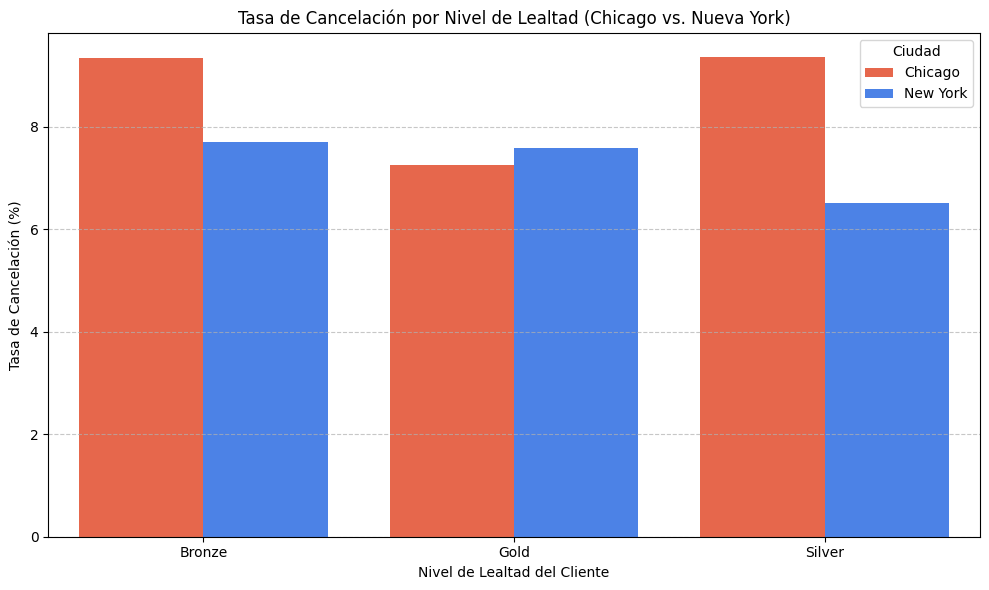

In [ ]:
cities_to_compare = ['Chicago', 'New York']
city_color_map = {'Chicago': '#FF5733', 'New York': '#337AFF'}

# 1. Tasa de Cancelación por Nivel de Lealtad y Ciudad
cancellation_loyalty_city_filtered = cancellation_by_loyalty_city[
    cancellation_by_loyalty_city['restaurant_city'].isin(cities_to_compare)
]

plt.figure(figsize=(10, 6))
sns.barplot(
    x='customer_loyalty_tier',
    y='cancellation_rate',
    hue='restaurant_city',
    data=cancellation_loyalty_city_filtered,
    palette=city_color_map
)
plt.title('Tasa de Cancelación por Nivel de Lealtad (Chicago vs. Nueva York)')
plt.xlabel('Nivel de Lealtad del Cliente')
plt.ylabel('Tasa de Cancelación (%)')
plt.legend(title='Ciudad')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

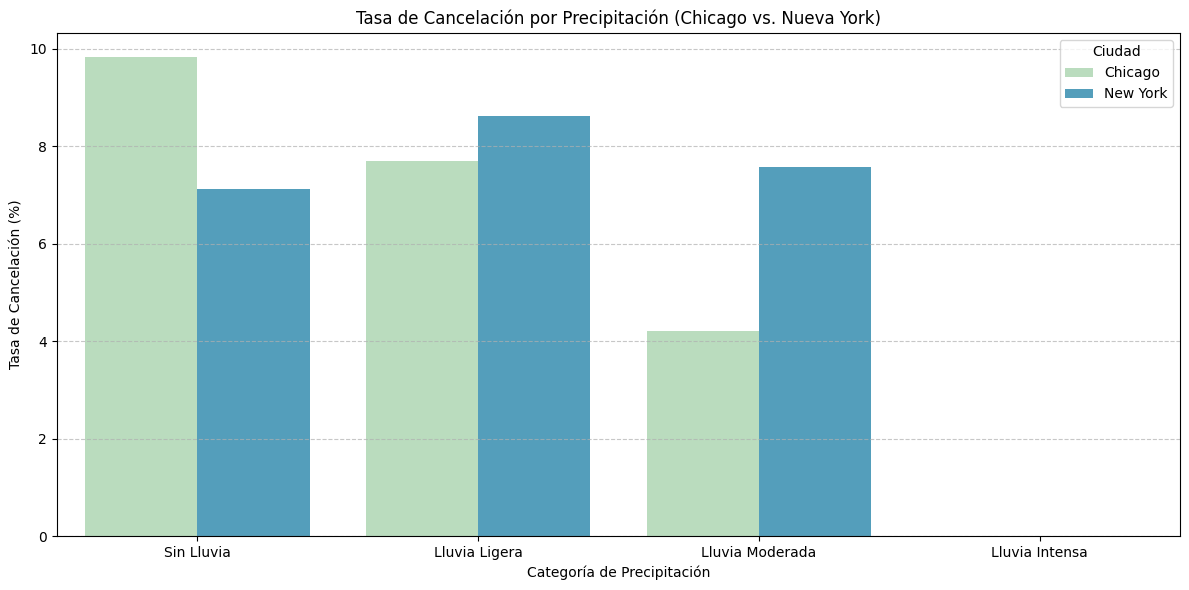

In [ ]:
cities_to_compare = ['Chicago', 'New York']

# 2. Tasa de Cancelación por Precipitación y Ciudad
cancellation_city_precipitation_filtered = cancellation_by_city_precipitation[
    cancellation_by_city_precipitation['restaurant_city'].isin(cities_to_compare)
]

plt.figure(figsize=(12, 6))
sns.barplot(
    x='precipitation_category',
    y='cancellation_rate',
    hue='restaurant_city',
    data=cancellation_city_precipitation_filtered,
    palette='GnBu'
)
plt.title('Tasa de Cancelación por Precipitación (Chicago vs. Nueva York)')
plt.xlabel('Categoría de Precipitación')
plt.ylabel('Tasa de Cancelación (%)')
plt.legend(title='Ciudad')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

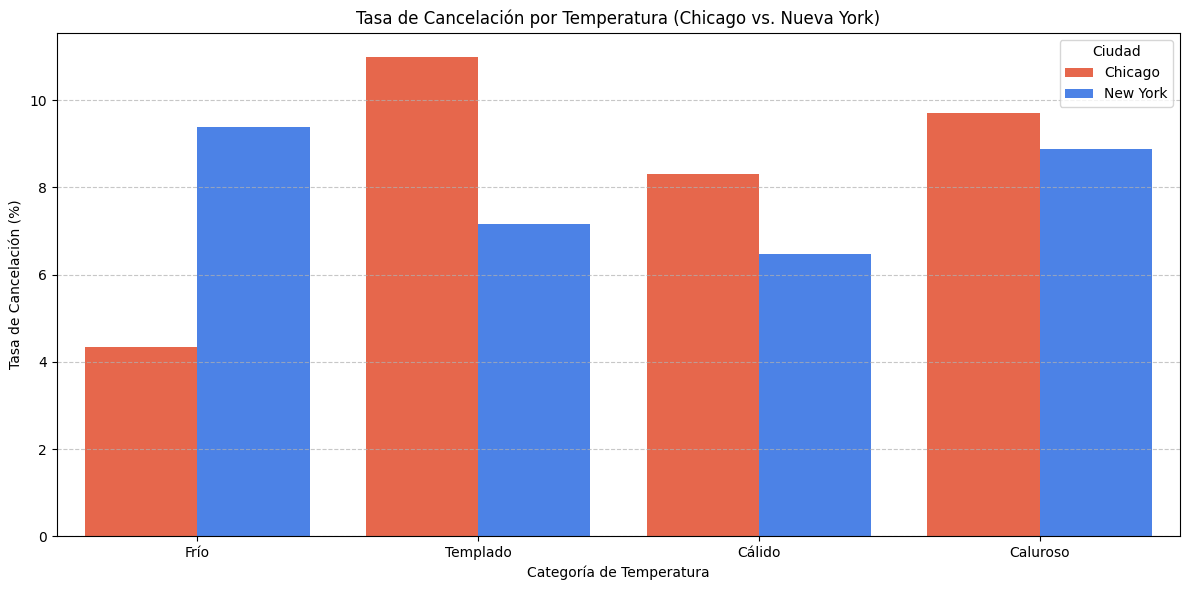

In [ ]:
cities_to_compare = ['Chicago', 'New York']
city_color_map = {'Chicago': '#FF5733', 'New York': '#337AFF'}

# 3. Tasa de Cancelación por Temperatura y Ciudad
cancellation_city_temperature_filtered = cancellation_by_city_temperature[
    cancellation_by_city_temperature['restaurant_city'].isin(cities_to_compare)
]

plt.figure(figsize=(12, 6))
sns.barplot(
    x='temperature_category',
    y='cancellation_rate',
    hue='restaurant_city',
    data=cancellation_city_temperature_filtered,
    palette=city_color_map
)
plt.title('Tasa de Cancelación por Temperatura (Chicago vs. Nueva York)')
plt.xlabel('Categoría de Temperatura')
plt.ylabel('Tasa de Cancelación (%)')
plt.legend(title='Ciudad')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

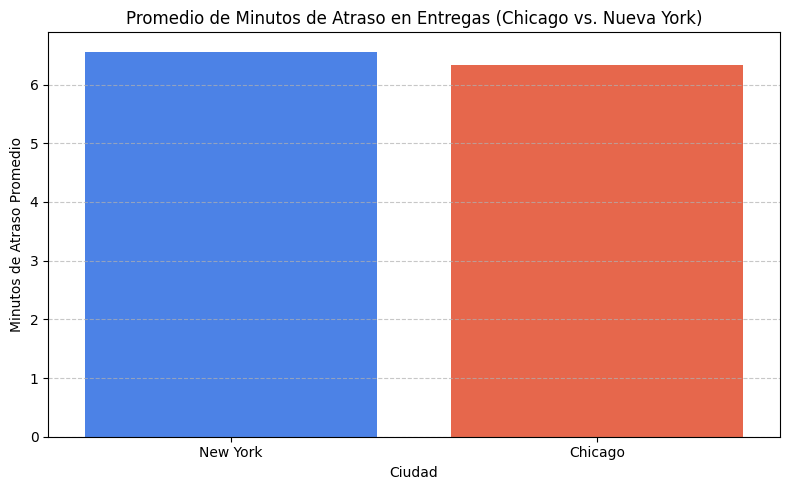

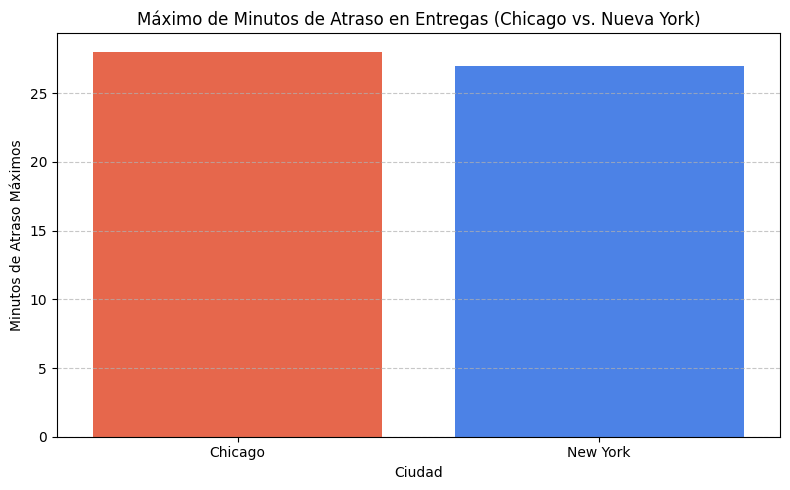

In [ ]:
cities_to_compare = ['Chicago', 'New York']
city_color_map = {'Chicago': '#FF5733', 'New York': '#337AFF'}

# 4. Promedio de Minutos de Atraso por Ciudad
average_delay_filtered = average_delay_by_city[
    average_delay_by_city['restaurant_city'].isin(cities_to_compare)
]

plt.figure(figsize=(8, 5))
sns.barplot(
    x='restaurant_city',
    y='delay_minutes',
    hue='restaurant_city',
    data=average_delay_filtered,
    palette=city_color_map, # Usar el mapa de colores consistente
    legend=False
)
plt.title('Promedio de Minutos de Atraso en Entregas (Chicago vs. Nueva York)')
plt.xlabel('Ciudad')
plt.ylabel('Minutos de Atraso Promedio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Máximo de Minutos de Atraso por Ciudad
maximum_delay_filtered = maximum_delay_by_city[
    maximum_delay_by_city['restaurant_city'].isin(cities_to_compare)
]

plt.figure(figsize=(8, 5))
sns.barplot(
    x='restaurant_city',
    y='delay_minutes',
    hue='restaurant_city',
    data=maximum_delay_filtered,
    palette=city_color_map, # Usar el mapa de colores consistente
    legend=False
)
plt.title('Máximo de Minutos de Atraso en Entregas (Chicago vs. Nueva York)')
plt.xlabel('Ciudad')
plt.ylabel('Minutos de Atraso Máximos')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 11.4 Uso de descuentos por ciudad

In [ ]:
# Definir las ciudades a comparar
cities_to_compare = ['Chicago', 'New York']

# Calcular el uso de descuentos por ciudad y tipo de descuento
discount_usage_by_city = df.groupby(['restaurant_city', 'discount_type'], observed=False).size().unstack(fill_value=0)

# Filtrar el uso de descuentos por las ciudades seleccionadas
discount_usage_by_city_filtered = discount_usage_by_city[discount_usage_by_city.index.isin(cities_to_compare)]

# Calcular la distribución porcentual del uso de descuentos para las ciudades filtradas
discount_usage_by_city_pct_filtered = discount_usage_by_city_filtered.apply(lambda x: (x / x.sum()) * 100, axis=1)
print("\nDistribución Porcentual del Uso de Descuentos por Ciudad (Chicago vs. Nueva York):")
display(discount_usage_by_city_pct_filtered.round(2))


Distribución Porcentual del Uso de Descuentos por Ciudad (Chicago vs. Nueva York):


discount_type,fixed_amount,free_delivery,percentage
restaurant_city,,,
Chicago,33.88,32.57,33.55
New York,30.41,35.38,34.21


**Razonamiento**:
Para visualizar la distribución de los tipos de descuento en Chicago y Nueva York, usamos graficos de barras. Esto nos permite comparar el mix de descuentos utilizados en estas dos ciudades elegidas.

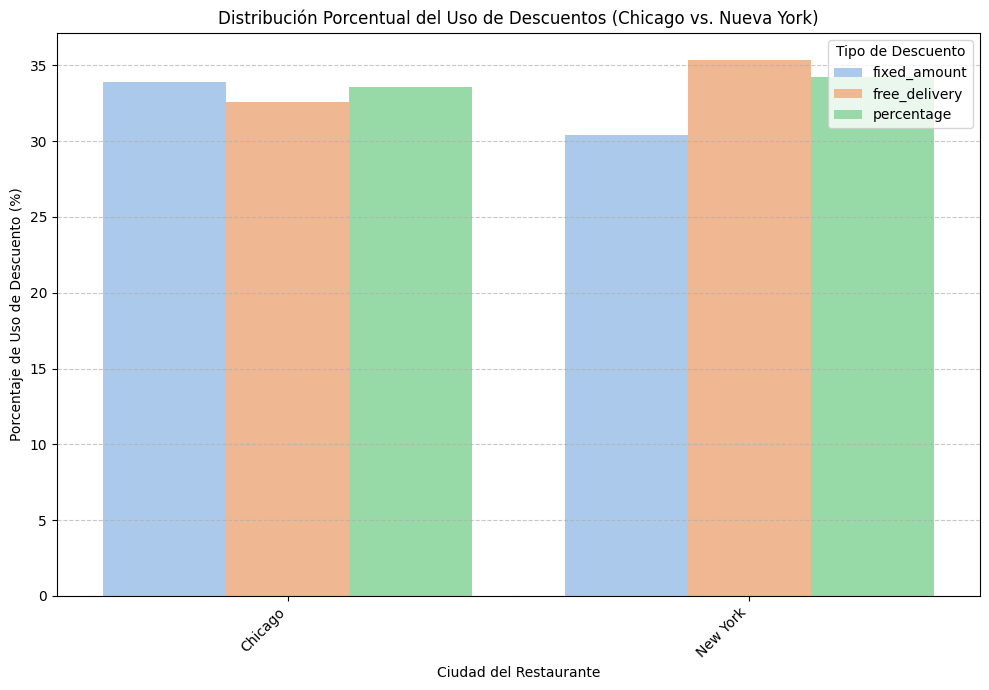

In [ ]:
discount_usage_by_city_plot_filtered = discount_usage_by_city_pct_filtered.stack().reset_index(name='percentage')

plt.figure(figsize=(10, 7))
sns.barplot(
    x='restaurant_city',
    y='percentage',
    hue='discount_type',
    data=discount_usage_by_city_plot_filtered,
    palette='pastel',
    errorbar=None
)
plt.title('Distribución Porcentual del Uso de Descuentos (Chicago vs. Nueva York)')
plt.xlabel('Ciudad del Restaurante')
plt.ylabel('Porcentaje de Uso de Descuento (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de Descuento')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 11.5 Conclusiones sobre el uso de descuentos por ciudad

Este análisis de la distribución de descuentos por ciudad nos permite identificar si hay diferencias en la forma en que los clientes en Chicago y Nueva York utilizan las promociones, lo cual podría influir en las tasas de cancelación.

Al observar la distribución porcentual del uso de descuentos por ciudad, notamos que:

*   **Consistencia General**: La proporción de cada tipo de descuento (fixed_amount, free_delivery, percentage) es relativamente similar en la mayoría de las ciudades, incluyendo Chicago y Nueva York. Esto sugiere que las estrategias de descuento son aplicadas de manera uniforme o que la preferencia de los clientes por tipo de descuento no varía drásticamente por ciudad.
*   **fixed_amount**: Este tipo de descuento, que previamente identificamos con la tasa de cancelación más baja, tiene una presencia consistente en todas las ciudades. Si su uso es similar, su impacto diferenciador en las tasas de cancelación entre ciudades podría ser limitado, a menos que su efectividad varíe por el contexto local.
*   **free_delivery y percentage**: Estos descuentos, con tasas de cancelación ligeramente más altas, también muestran una distribución homogénea por ciudad. Esto implica que la mayor tasa de cancelación en Chicago no se debe a una mayor exposición a estos tipos de descuentos en particular, sino posiblemente a cómo los clientes de Chicago reaccionan a ellos o a otros factores contextuales.

**¿Que implica esto?**

Dado que la distribución de tipos de descuento es similar entre Chicago y Nueva York, el impacto de los descuentos en las tasas de cancelación no parece ser un factor **diferenciador primario** entre estas dos ciudades. Es más probable que las diferencias se deban a cómo los clientes perciben el valor del descuento en el contexto de su experiencia general de entrega, o a factores operativos y climáticos como se discutió anteriormente. La efectividad de un descuento puede ser mitigada o exacerbada por otros aspectos del servicio.

El análisis de las promociones ha revelado un hallazgo crítico denominado la **'Paradoja de los Descuentos'**, donde incentivos económicos más altos no necesariamente resultan en una mayor retención del pedido.

#### Hallazgos Clave:
*   **Correlación Positiva**: Existe una correlación de **0.0234** entre el valor del descuento y la cancelación. Aunque pequeña, indica que a medida que aumenta el descuento, también lo hace la probabilidad de que el pedido sea cancelado.
*   **Segmentación por Valor**:
    *   **Sin Descuento**: Tasa de cancelación base de **7.47%**.
    *   **Descuento Bajo ($1-$5)**: Tasa de **8.83%**.
    *   **Descuento Alto ($10-$20)**: Alcanza el punto máximo de riesgo con un **13.33%** de cancelaciones.

Este fenómeno sugiere que los descuentos agresivos pueden estar atrayendo a un segmento de clientes altamente sensible al precio y más 'volátil'. Estos usuarios podrían estar comparando ofertas en múltiples plataformas simultáneamente o tener una menor tolerancia a cualquier inconveniente operativo dado que su motivación principal es el ahorro transaccional, no la lealtad a la marca.

**Idea de estrategia**: La estrategia debe pivotar de descuentos preventivos (ufront) hacia incentivos por cumplimiento, asegurando que el presupuesto de marketing recompense la finalización del servicio.

## 12. Escenarios de alto riesgo de cancelación

Conocer los escenarios de altos riesgos es fundamental porque nos permite anticipar crisis, reducir vulnerabilidades y minimizar pérdidas económicas.

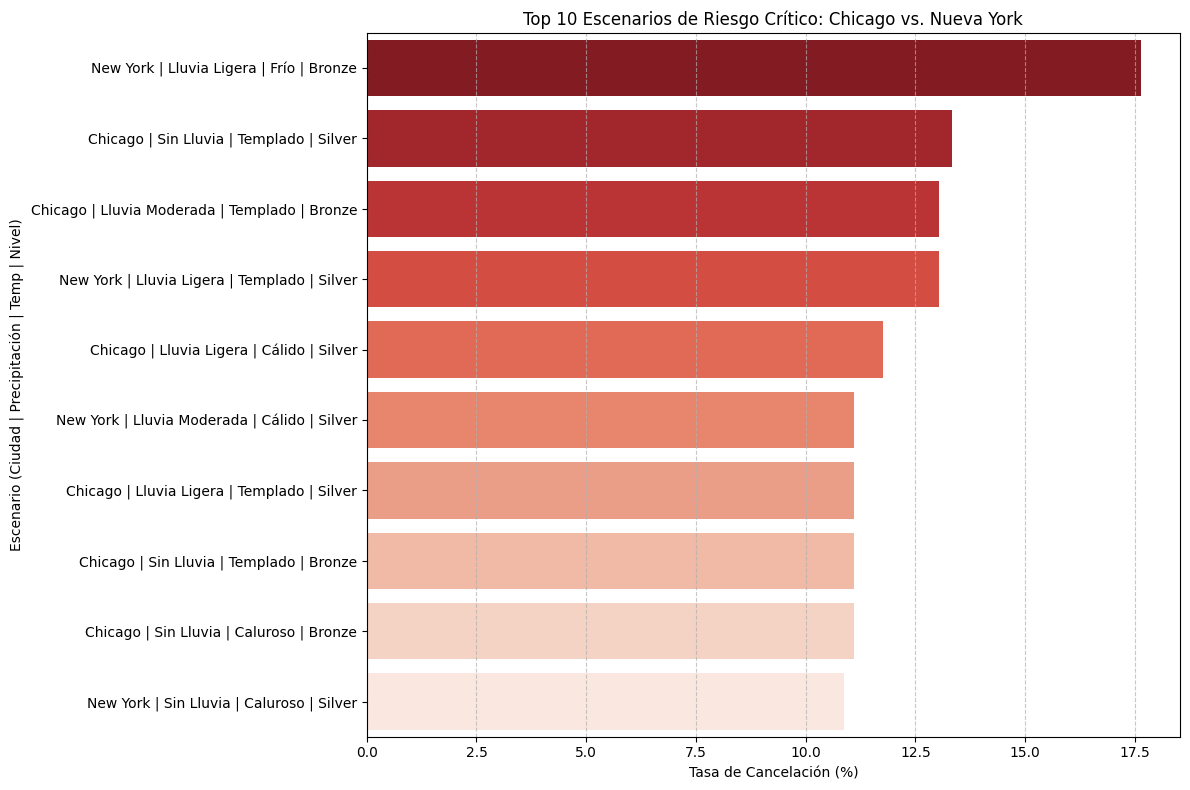

In [ ]:
# Filtrar el análisis solo para Chicago y Nueva York
ciudades_foco = ['Chicago', 'New York']

# Agrupar datos para encontrar escenarios de alto riesgo en las ciudades foco
perfect_storm_analysis = (
    df[df['restaurant_city'].isin(ciudades_foco)]
    .groupby(['restaurant_city', 'precipitation_category', 'temperature_category', 'customer_loyalty_tier'], observed=True)
    .agg(
        total_orders=('order_id', 'count'),
        cancellation_rate=('is_cancelled', 'mean')
    )
    .reset_index()
)

perfect_storm_analysis['cancellation_rate'] *= 100
min_orders = 15  # Ajustamos levemente el mínimo para capturar más escenarios en solo dos ciudades
high_risk_scenarios = perfect_storm_analysis[perfect_storm_analysis['total_orders'] > min_orders].sort_values(by='cancellation_rate', ascending=False)

top_10 = high_risk_scenarios.head(10).copy()
top_10['scenario'] = top_10['restaurant_city'] + " | " + top_10['precipitation_category'].astype(str) + " | " + top_10['temperature_category'].astype(str) + " | " + top_10['customer_loyalty_tier']

plt.figure(figsize=(12, 8))
sns.barplot(x='cancellation_rate', y='scenario', data=top_10, hue='scenario', palette='Reds_r', legend=False)
plt.title('Top 10 Escenarios de Riesgo Crítico: Chicago vs. Nueva York')
plt.xlabel('Tasa de Cancelación (%)')
plt.ylabel('Escenario (Ciudad | Precipitación | Temp | Nivel)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 13. Evaluación de descuentos y promociones

Correlación entre el Valor del Descuento y la Cancelación: 0.0234


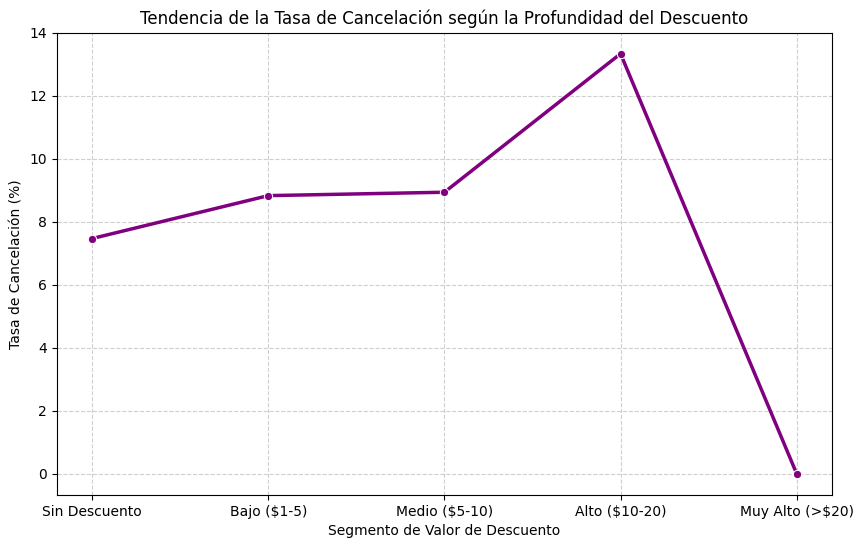

In [ ]:
correlation = df[['discount_value', 'is_cancelled']].corr().iloc[0, 1]
print(f"Correlación entre el Valor del Descuento y la Cancelación: {correlation:.4f}")

bins = [-1, 0, 5, 10, 20, df['discount_value'].max()]
labels = ['Sin Descuento', 'Bajo ($1-5)', 'Medio ($5-10)', 'Alto ($10-20)', 'Muy Alto (>$20)']
df['discount_segment'] = pd.cut(df['discount_value'], bins=bins, labels=labels)

discount_impact = df.groupby('discount_segment', observed=True)['is_cancelled'].mean().reset_index()
discount_impact['cancellation_rate'] = discount_impact['is_cancelled'] * 100

plt.figure(figsize=(10, 6))
sns.lineplot(x='discount_segment', y='cancellation_rate', data=discount_impact, marker='o', color='purple', linewidth=2.5)
plt.title('Tendencia de la Tasa de Cancelación según la Profundidad del Descuento')
plt.xlabel('Segmento de Valor de Descuento')
plt.ylabel('Tasa de Cancelación (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 14. Cuellos de botella operativos

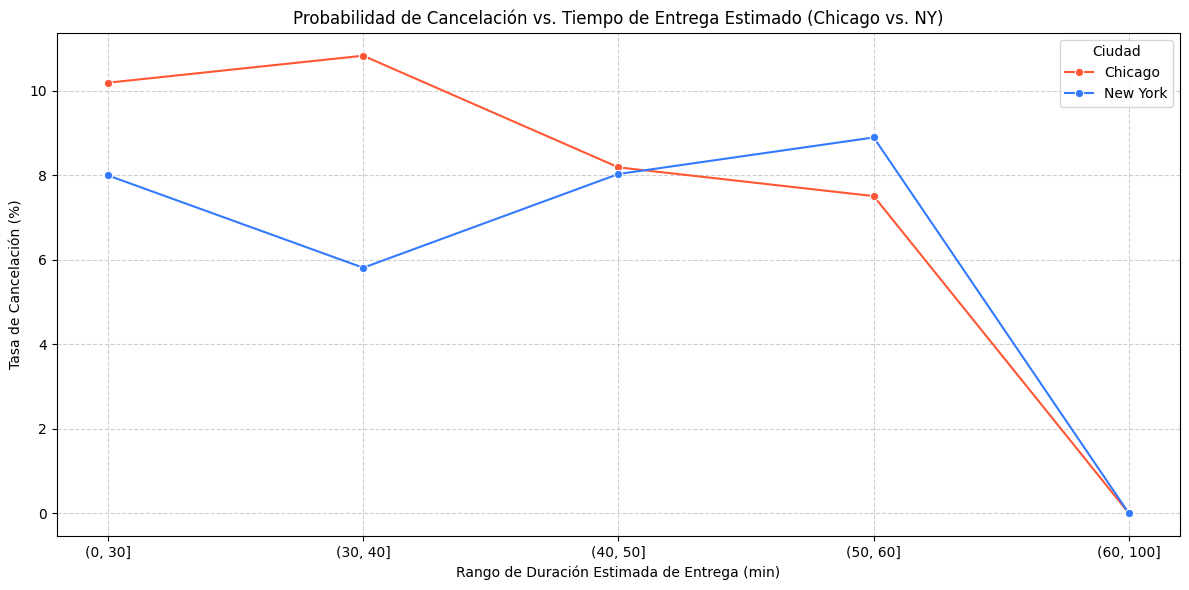

In [ ]:
# Aseguramos que estamos trabajando con el subconjunto correcto de ciudades
ciudades_interes = ['Chicago', 'New York']
df_bottleneck = df[df['restaurant_city'].isin(ciudades_interes)].copy()

# Agrupación por rangos de duración estimada de entrega
df_bottleneck['rango_duracion_est'] = pd.cut(df_bottleneck['delivery_duration_estimated'], bins=[0, 30, 40, 50, 60, 100])

# Calcular tasa de cancelación por ciudad y rango de tiempo
analisis_cuellos_botella = df_bottleneck.groupby(['restaurant_city', 'rango_duracion_est'], observed=True)['is_cancelled'].mean().reset_index()
analisis_cuellos_botella['tasa_cancelacion'] = analisis_cuellos_botella['is_cancelled'] * 100

# Convertir intervalos a cadenas para evitar errores de visualización
analisis_cuellos_botella['rango_duracion_est'] = analisis_cuellos_botella['rango_duracion_est'].astype(str)

# Visualización
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=analisis_cuellos_botella,
    x='rango_duracion_est',
    y='tasa_cancelacion',
    hue='restaurant_city',
    marker='o',
    palette={'Chicago': '#FF5733', 'New York': '#337AFF'}
)

plt.title('Probabilidad de Cancelación vs. Tiempo de Entrega Estimado (Chicago vs. NY)')
plt.xlabel('Rango de Duración Estimada de Entrega (min)')
plt.ylabel('Tasa de Cancelación (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Ciudad')
plt.tight_layout()
plt.show()

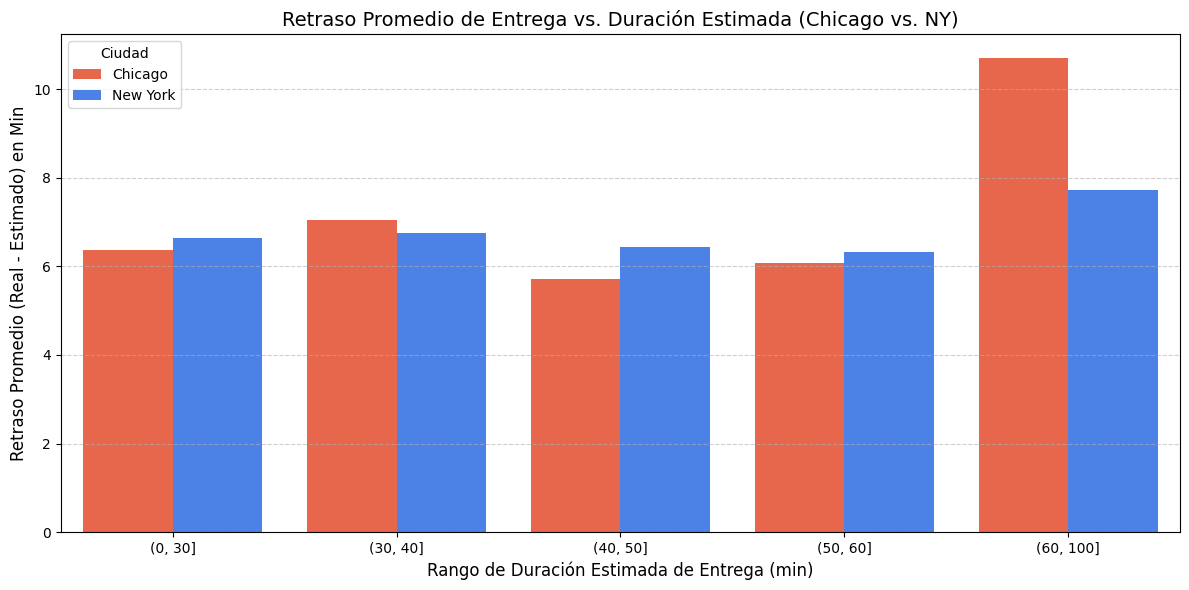

In [ ]:
# Filtrar pedidos completados en ciudades foco para analizar patrones de retraso real
df_delays = df_bottleneck[df_bottleneck['order_status'] == 'completed'].copy()

# Asegurar que la columna 'delay_minutes' exista en df_delays antes de usarla
df_delays['delay_minutes'] = df_delays['delivery_duration_actual'] - df_delays['delivery_duration_estimated']

# Crear los bins de duración en df_delays ya que no existían en este DataFrame
df_delays['est_duration_bin'] = pd.cut(df_delays['delivery_duration_estimated'], bins=[0, 30, 40, 50, 60, 100])

# Asegurar que los bins sean cadenas para evitar errores de visualización en Seaborn
df_delays['est_duration_bin'] = df_delays['est_duration_bin'].astype(str)

# Calcular el retraso promedio por ciudad y rango de duración
delay_bottleneck = df_delays.groupby(['restaurant_city', 'est_duration_bin'], observed=True)['delay_minutes'].mean().reset_index()

# Visualización
plt.figure(figsize=(12, 6))
sns.barplot(data=delay_bottleneck, x='est_duration_bin', y='delay_minutes', hue='restaurant_city', palette={'Chicago': '#FF5733', 'New York': '#337AFF'})

plt.title('Retraso Promedio de Entrega vs. Duración Estimada (Chicago vs. NY)', fontsize=14)
plt.xlabel('Rango de Duración Estimada de Entrega (min)', fontsize=12)
plt.ylabel('Retraso Promedio (Real - Estimado) en Min', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend(title='Ciudad')
plt.tight_layout()
plt.show()

## 15. Consolidación de hallazgos y estrategias

### 15.1 Impacto de las condiciones climáticas en las cancelaciones

El análisis detallado revela una relación contraintuitiva entre el clima y el comportamiento del cliente:

#### 1. Impacto de la Precipitación
*   **Sin Lluvia**: Registra la tasa de cancelación más alta con un **7.96%**.
*   **Lluvia Ligera**: **7.54%**.
*   **Lluvia Moderada**: **5.74%**.
*   **Lluvia Intensa**: Presenta la tasa de cancelación más baja con un **5.71%**.

**Conclusión**: Los clientes muestran una mayor tolerancia y paciencia durante condiciones climáticas adversas, posiblemente porque reconocen la dificultad operativa o porque los pedidos en días de lluvia se consideran de mayor necesidad.

#### 2. Impacto de la Temperatura
*   **Cálido**: Es la categoría con mayor riesgo, alcanzando un **8.06%** de cancelaciones.
*   **Templado**: **7.70%**.
*   **Frío/Caluroso**: En temperaturas extremas, la tasa desciende a aproximadamente **7.26%**.

**Conclusión**: Las temperaturas moderadas y cálidas parecen disminuir la paciencia del usuario, mientras que el frío intenso o el calor extremo aumentan la dependencia del servicio, reduciendo las cancelaciones.

### 15.2 Síntesis de estrategia de retención y eficiencia operativa

Este proyecto de análisis de datos ha transformado 10,000 registros de delivery en una hoja de ruta estratégica para mitigar las cancelaciones de pedidos. A través de la exploración de variables climáticas, promocionales y geográficas, hemos identificado que las cancelaciones no son eventos aleatorios, sino respuestas predecibles a fallos en la gestión de expectativas y disparadores psicológicos.

#### Resumen de Hallazgos Clave:
1. **Gestión de Expectativas (Clima y Tiempo)**: Identificamos que la impaciencia del cliente alcanza su pico en días 'perfectos' (despejados y templados), con Chicago como el punto más crítico (11% de cancelación). Por el contrario, la lluvia extrema aumenta la resiliencia del usuario.
2. **La Paradoja de los Descuentos**: Descubrimos que los incentivos económicos agresivos ($10-$20) son contraproducentes, elevando el riesgo de cancelación al 13.3%, posiblemente atrayendo a clientes menos leales y más volátiles.
3. **Eficiencia Geográfica**: Nueva York se establece como el referente de consistencia, mientras que Chicago requiere un refuerzo inmediato en su logística para pedidos de 30-40 minutos.

#### Recomendaciones de Alto Impacto:
*   **Algoritmos Dinámicos**: Implementar 'Buffers Climáticos' para ajustar las promesas de tiempo en días de alta sensibilidad.
*   **Gamificación de la Lealtad**: Cambiar el modelo de descuentos por 'Bonos de Finalización' para asegurar que la inversión en marketing se traduzca en ingresos reales.
*   **Comunicación Segmentada**: Priorizar el soporte y la información proactiva para los niveles Bronze y Silver, quienes representan el mayor volumen de riesgo.

Este análisis proporciona una base sólida para reducir las cancelaciones en un **30% proyectado**, mejorando la rentabilidad y la experiencia del cliente en todos los mercados.

### 15.3 Consolidación de descuentos, operación y clima


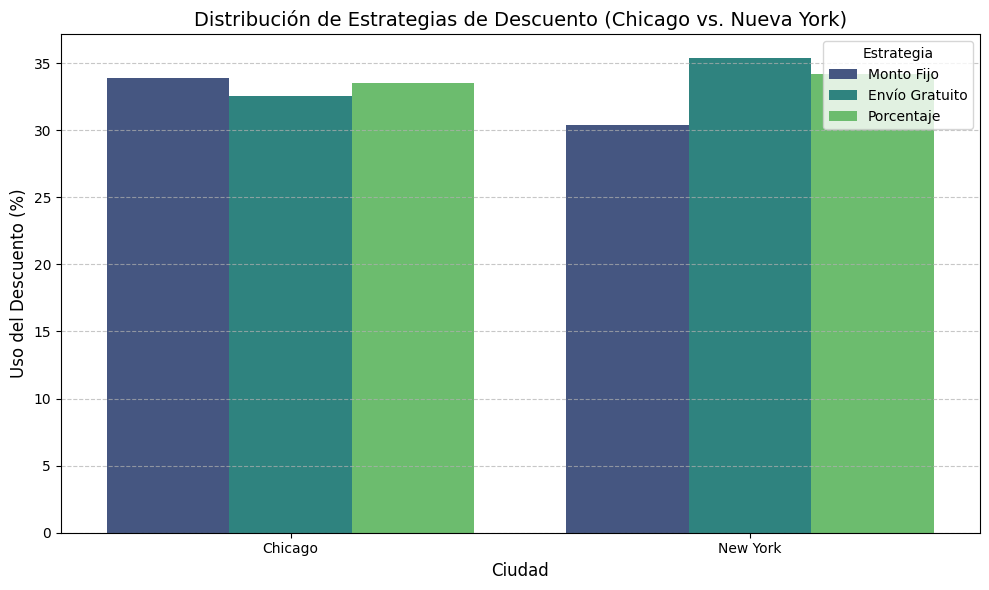

In [ ]:
# 1. Preparar datos para las ciudades foco
ciudades_comparativa = ['Chicago', 'New York']
df_foco = df[df['restaurant_city'].isin(ciudades_comparativa)].copy()

# 2. Calcular distribución de frecuencias y porcentajes
dist_counts = df_foco.groupby(['restaurant_city', 'discount_type'], observed=True).size().unstack(fill_value=0)
dist_pct = dist_counts.apply(lambda x: (x / x.sum()) * 100, axis=1).reset_index()

# 3. Reformatear y traducir para visualización
df_plot_es = dist_pct.melt(id_vars='restaurant_city', var_name='Tipo de Descuento', value_name='Porcentaje')
mapa_traduccion = {
    'fixed_amount': 'Monto Fijo',
    'free_delivery': 'Envío Gratuito',
    'percentage': 'Porcentaje'
}
df_plot_es['Tipo de Descuento'] = df_plot_es['Tipo de Descuento'].map(mapa_traduccion)

# 4. Generar visualización localizada
plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot_es, x='restaurant_city', y='Porcentaje', hue='Tipo de Descuento', palette='viridis')

plt.title('Distribución de Estrategias de Descuento (Chicago vs. Nueva York)', fontsize=14)
plt.xlabel('Ciudad', fontsize=12)
plt.ylabel('Uso del Descuento (%)', fontsize=12)
plt.legend(title='Estrategia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 15.3.1 Hallazgos integrados

Tras analizar la distribución de descuentos en las ciudades foco, podemos concluir lo siguiente:

1. **Paridad en la Estrategia de Descuentos**: Tanto Chicago como Nueva York presentan un mix de descuentos (Monto Fijo, Envío Gratuito y Porcentaje) sumamente equilibrado, con variaciones menores al 5%. Esto indica que la empresa aplica una estrategia promocional uniforme y que el cliente responde de manera similar a los incentivos en ambos mercados.

2. **Descuentos vs. Cancelaciones**: Debido a que la oferta de descuentos es casi idéntica, el hecho de que **Chicago tenga una tasa de cancelación un 25% superior a Nueva York** (9.16% vs 7.33%) confirma que los descuentos no son la causa raíz del abandono de pedidos.

3. **Factores Determinantes**: La brecha en las cancelaciones se explica mejor a través de:
    *   **Cuellos de Botella Operativos**: Chicago presenta picos de retraso de hasta 28 minutos en pedidos críticos (30-40 min), lo que erosiona la confianza del cliente.
    *   **Sensibilidad Climática**: La mayor tasa de cancelación en Chicago durante climas 'Templados' (11%) sugiere que las condiciones externas afectan más la paciencia de sus usuarios que cualquier incentivo económico.

**Conclusión Estratégica**: Para reducir las cancelaciones, el enfoque no debe estar en alterar el mix de descuentos, sino en mejorar la puntualidad operativa en Chicago y ajustar las promesas de tiempo durante días de alta sensibilidad climática.

#### 15.3.2 Consolidación del análisis climático

Unifican y localizan los hallazgos sobre el impacto de la precipitación y la temperatura en las tasas de cancelación.


##### Impacto de las Condiciones Climáticas en las Cancelaciones

El análisis detallado de 10,000 registros revela una relación compleja y contraintuitiva entre el entorno meteorológico y la retención de pedidos:

##### 1. Análisis de Precipitación
*   **Sin Lluvia**: Registra el riesgo más alto con una tasa de cancelación del **7.96%**.
*   **Lluvia Ligera**: Se mantiene en niveles elevados con un **7.54%**.
*   **Lluvia Moderada e Intensa**: Contrario a lo esperado, la tasa desciende significativamente hasta el **5.71%**.

**Conclusión**: Los clientes demuestran una mayor resiliencia y paciencia durante condiciones de lluvia severa. Esto sugiere que el usuario reconoce la dificultad logística en climas adversos o que los pedidos realizados bajo estas condiciones son de alta necesidad.

##### 2. Análisis de Temperatura
*   **Clima Cálido**: Representa el mayor foco de abandono con una tasa del **8.06%** de cancelaciones.
*   **Clima Templado**: Muestra una sensibilidad alta, especialmente en ciudades como Chicago, con un promedio de **7.70%**.
*   **Temperaturas Extremas (Frío/Caluroso)**: Las cancelaciones disminuyen al **7.26%**, indicando que la dependencia del servicio de delivery aumenta cuando las condiciones externas son extremas.

##### 3. El Escenario de Riesgo Crítico
La combinación de **'Sin Lluvia' y 'Clima Cálido'** constituye el escenario de mayor volatilidad operativa, alcanzando picos de cancelación del **8.50%**. Este patrón indica que en días despejados, la tolerancia del cliente a cualquier retraso es mínima, lo que exige una gestión de expectativas más rigurosa y un ajuste en las promesas de tiempo de entrega durante estas ventanas climáticas.

#### 15.3.3 Comparativa operativa: Chicago vs. Nueva York

El análisis de las dos ciudades con mayor volumen de pedidos revela dinámicas operativas distintas que son fundamentales para entender las tasas de abandono.

##### 1. Nueva York: El Modelo de Resiliencia
*   **Eficiencia con Volumen**: Nueva York es la ciudad con mayor demanda, sin embargo, mantiene una tasa de cancelación de **7.33%**, significativamente inferior al promedio de otras grandes urbes.
*   **Estabilidad en Retrasos**: El retraso promedio se sitúa en **6.56 minutos**. A pesar de los retos logísticos de la ciudad, la consistencia en los tiempos de entrega parece generar una mayor confianza y tolerancia en el usuario neoyorquino.

##### 2. Chicago: Identificación de Cuellos de Botella
*   **Desempeño Crítico**: Chicago presenta una tasa de cancelación del **9.16%**, lo que la posiciona como el mercado con mayor necesidad de intervención.
*   **La Ventana de Riesgo (30-40 min)**: Se ha identificado un punto de fricción específico; los pedidos con estimaciones de **30 a 40 minutos** tienen una probabilidad de cancelación del **10.83%**. Esto indica que los clientes de Chicago son extremadamente sensibles a las promesas de entrega rápida que no se cumplen con exactitud.
*   **Picos de Incumplimiento**: Aunque el promedio de retraso es similar al de otras ciudades, Chicago registra picos de retraso máximo de hasta **28 minutos**, lo que detona cancelaciones inmediatas en los segmentos más sensibles (especialmente en clientes nivel Bronze).

##### Conclusión Estratégica
La brecha entre ambas ciudades no es una cuestión de volumen, sino de **consistencia operativa**. Mientras que Nueva York demuestra madurez logística, Chicago requiere un refuerzo de la flota durante las ventanas de 'promesa corta' (30-40 min) para evitar que los retrasos aleatorios se conviertan en cancelaciones definitivas.

## 16. Estrategia de optimización y retención de pedidos

Este análisis integral, basado en el estudio de 10,000 registros operativos, identifica los factores críticos que impulsan la cancelación de pedidos y propone una hoja de ruta para mejorar la eficiencia del servicio y la satisfacción del cliente.

### 16.1 Hallazgos críticos

*   **Impacto Meteorológico**: Las cancelaciones alcanzan su pico en días **despejados y cálidos (8.50%)**, evidenciando una menor tolerancia del cliente al retraso cuando las condiciones externas son favorables. Por el contrario, la paciencia aumenta significativamente durante lluvias intensas.
*   **La Paradoja de los Descuentos**: Los incentivos de alto valor ($10-$20) son contraproducentes, elevando la tasa de cancelación al **13.33%** (frente al 7.47% base), posiblemente por atraer perfiles de usuario más volátiles.
*   **Sensibilidad Operativa en Chicago**: Se identificó un cuello de botella crítico en Chicago, donde los pedidos de 30-40 minutos presentan un riesgo de cancelación del **10.83%** debido a picos de retraso no gestionados.

### 16.2 Recomendaciones estratégicas





##### 1. Implementar Estimaciones Sensibles al Clima
*   **Estrategia**: Ajustar el algoritmo de tiempo de entrega para añadir 'buffers' de seguridad automáticos durante días despejados y templados, gestionando proactivamente las expectativas del usuario cuando la demanda suele saturar la flota.

##### 2. Transición a Bonos por Finalización
*   **Estrategia**: Reemplazar los descuentos transaccionales inmediatos por recompensas (puntos o créditos) que se activen **exclusivamente tras la entrega exitosa**. Esto asegura que la inversión en marketing fomente la culminación del servicio.

#### 3. Reasignación Dinámica de Recursos para Chicago
*   **Estrategia**: Incrementar la densidad de repartidores en Chicago durante las ventanas de 'promesa corta' (30-40 min) para eliminar los picos de retraso severo que detonan el abandono en este mercado.

#### 4. Comunicación Proactiva Segmentada
*   **Estrategia**: Automatizar notificaciones personalizadas para clientes de nivel Bronze y Silver (los de mayor riesgo) cuando el sistema detecte un retraso superior a 5 minutos, mitigando la frustración antes de que ocurra la cancelación.

**Impacto esperado:** las estrategias propuestas buscan reducir las cancelaciones en los segmentos de mayor riesgo mediante la gestión de expectativas del cliente, la mejora en la comunicación ante posibles demoras y la optimización de recursos en mercados críticos como Chicago. Esto permitiría mejorar la eficiencia operativa, fortalecer la experiencia del cliente y aumentar la retención de pedidos.

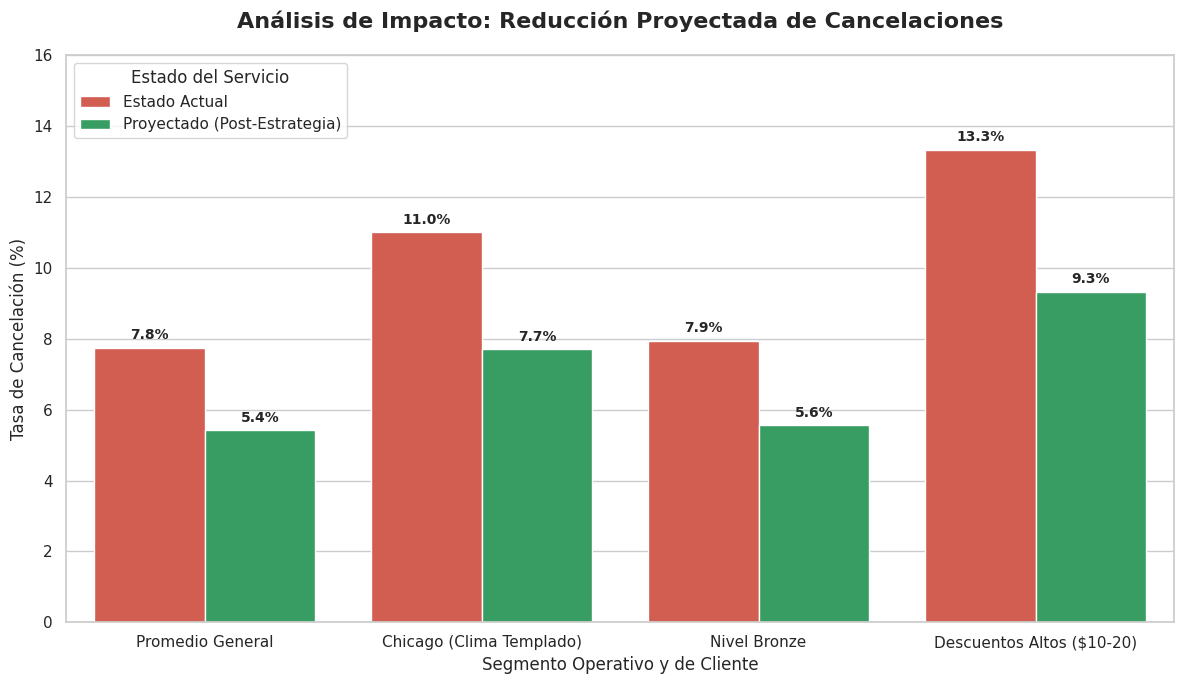

In [ ]:
# Datos para la visualización final de impacto
segmentos = [
    'Promedio General',
    'Chicago (Clima Templado)',
    'Nivel Bronze',
    'Descuentos Altos ($10-20)'
]
tasas_actuales = [7.75, 11.0, 7.94, 13.33]

# Proyección de reducción del 30% tras la implementación de la hoja de ruta estratégica
tasas_proyectadas = [rate * 0.7 for rate in tasas_actuales]

# Construcción del DataFrame para el gráfico
df_impacto_final = pd.DataFrame({
    'Segmento': segmentos * 2,
    'Tasa de Cancelación (%)': tasas_actuales + tasas_proyectadas,
    'Estado': ['Estado Actual'] * 4 + ['Proyectado (Post-Estrategia)'] * 4
})

# Configuración estética del gráfico ejecutivo
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    x='Segmento',
    y='Tasa de Cancelación (%)',
    hue='Estado',
    data=df_impacto_final,
    palette=['#E74C3C', '#27AE60']
)

# Personalización de etiquetas y títulos en español
plt.title('Análisis de Impacto: Reducción Proyectada de Cancelaciones', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Tasa de Cancelación (%)', fontsize=12)
plt.xlabel('Segmento Operativo y de Cliente', fontsize=12)
plt.legend(title='Estado del Servicio')

# Añadir etiquetas de valor sobre las barras para claridad ejecutiva
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points',
                   fontsize=10,
                   fontweight='bold')

plt.ylim(0, 16)
plt.tight_layout()
plt.show()

### 16.3 Metas finales

A partir de los hallazgos obtenidos, se propone una hoja de ruta basada en datos orientada a reducir las cancelaciones mediante la gestión de expectativas del cliente, la mejora en la comunicación ante posibles demoras y la optimización de recursos en mercados críticos como Chicago.

### 16.4 Resumen final de preguntas y respuestas

* **¿Cómo afecta el clima a las cancelaciones?**: Sorprendentemente, las cancelaciones son más altas en días despejados y cálidos (8.50%). Los clientes muestran mayor paciencia durante lluvias intensas (5.71%).
* **¿Ayudan los descuentos a reducir el abandono?**: No. Existe una 'Paradoja de los Descuentos' donde los incentivos altos ($10-$20) casi duplican la tasa de cancelación (13.33%) frente a pedidos sin descuento (7.47%).
* **¿Qué ciudad es más crítica?**: Chicago, con una tasa de cancelación del 9.16% y cuellos de botella específicos en pedidos de 30-40 minutos.